# Laboratorio: Laplace en 2D, cinco puntos contra Monte Carlo, e inpainting — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-laplace-datos.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-laplace-datos.ipynb`.

En el Capítulo 19 vimos que el problema de Dirichlet para la ecuación de Laplace, $\Delta u = 0$ en $\Omega$ con $u = g$ en $\partial\Omega$, se puede mirar de tres maneras que dicen lo mismo: como **ecuación de promedios** (el valor en cada punto es el promedio de sus vecinos), como **juego** (el valor esperado del pago $g$ de un paseo al azar que empieza en el punto y termina al tocar el borde) y como **problema variacional** (la función con menos energía $\int|\nabla u|^2$ que vale $g$ en el borde). Cada mirada da un algoritmo distinto, y cada algoritmo tiene su costo, sus errores y su lugar. Este laboratorio los pone a competir y, al final, los usa para algo que se ve: **rellenar un agujero en una fotografía**.

**Qué vamos a hacer.** Ensamblar el esquema de cinco puntos como un sistema lineal ralo, resolverlo y verificarlo contra la solución exacta por series de Fourier (Tarea 1); medir cuánto cuesta en tiempo y memoria, denso contra ralo (Tarea 2); resolver "jugando", con Monte Carlo, y medir cómo baja el error con el número de partidas (Tarea 3); comparar los costos de los dos métodos y ver qué pasa en dimensión alta (Tarea 4); resolver el sistema con métodos iterativos que son literalmente "promediar una y otra vez" y contar cuántas iteraciones hacen falta (Tarea 5); agregar una fuente, $-\Delta u = f$, y ver cómo cambia el juego (Tarea 6); y por último el **inpainting**: borrar una región de una imagen y rellenarla resolviendo Laplace con los píxeles del borde de la región como dato, en un fondo liso y en una textura (Tarea 7). La Tarea 8, opcional, usa una fuente $f$ construida a partir de otra parte de la imagen (clonado de textura, "Poisson image editing").

**Lo que las notas no explican y este notebook sí.** Cómo se ensambla el esquema de cinco puntos como matriz (con `scipy.sparse`) y qué cuesta resolverlo; los métodos iterativos (Jacobi, Gauss–Seidel, gradiente conjugado) y por qué los primeros son lentos; el error estadístico de Monte Carlo y su costo, comparado con el error de discretización; el juego con fuente (la versión discreta de la fórmula de Feynman–Kac); y la formulación del inpainting como un sistema lineal ralo sobre los píxeles de una región de forma arbitraria. El texto de las secciones 1 a 6 es la única presentación que van a tener de estos temas: léanlo, no solo las consignas.

**Herramientas disponibles.** `scipy.sparse` y `scipy.sparse.linalg`, `numpy`, `imc.numerico.laplaciano_2d` y `imc.numerico.poisson_cinco_puntos` (**para verificar** lo que ensamblen ustedes, no para reemplazarlo), `imc.datos.obtener` (la imagen `astronauta.png`), `imc.estilo`. El notebook `10-laplace` de las notas ya hizo, en $n=20$, la comparación cualitativa entre Monte Carlo y cinco puntos, el principio del máximo y el valor medio; acá lo hacemos en serio: con escalas, costos y verificaciones cuantitativas.

**Cómo se evalúa.** Como siempre: la sección final de **interpretación escrita**. Cada tarea dice qué se espera y trae una celda de verificación. Tiempo estimado: una sesión de 4 h para las Tareas 1 a 7; la Tarea 8 es opcional.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from imc import numerico
from imc.estilo import CICLO
estilo.activar()

In [2]:
# Convenciones del laboratorio (esta celda viene dada)
# Cuadrado unitario, n intervalos por lado, paso h = 1/n; u[i, j] es el valor en (x_j, y_i) = (j h, i h):
# la fila i = n es el lado superior (y = 1) y la columna j = n el lado derecho (x = 1).
# Un "dato de borde" G es un array (n+1, n+1) del que solo se usan los valores del borde (sin las esquinas).

def mapa_color(ax, U, titulo="", vmin=None, vmax=None, cmap="viridis"):
    """Dibuja el array U (n+1, n+1) como mapa de color sobre el cuadrado unitario."""
    h = 1 / (U.shape[0] - 1)
    im = ax.imshow(U, origin="lower", extent=[-h / 2, 1 + h / 2, -h / 2, 1 + h / 2], vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title(titulo)
    return im

## 1. El esquema de cinco puntos: promedios, matriz y solución exacta

### La ecuación de promedios

Sea $h = 1/n$ y los nodos $(x_j, y_i) = (jh, ih)$, $0\le i,j\le n$. El desarrollo de Taylor da, para $u$ suave,

$$u(x+h,y) + u(x-h,y) - 2u(x,y) = h^2 u_{xx} + \tfrac{h^4}{12}u_{xxxx} + O(h^6),$$

y lo mismo en $y$. Sumando, el **Laplaciano discreto de cinco puntos** es

$$\Delta_h u\,(x,y) = \frac{u(x+h,y) + u(x-h,y) + u(x,y+h) + u(x,y-h) - 4u(x,y)}{h^2} = \Delta u + \frac{h^2}{12}\,(u_{xxxx} + u_{yyyy}) + O(h^4).$$

El error de consistencia es $O(h^2)$: **se espera orden 2**. La ecuación discreta $\Delta_h u = 0$ en un nodo interior dice exactamente

$$u_{i,j} = \frac{1}{4}\bigl(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1}\bigr),$$

es decir, **cada valor es el promedio de sus cuatro vecinos**. Esa es la ecuación de promedios del juego aleatorio, sin ningún límite: el esquema de cinco puntos *es* la ecuación de promedios. Con una fuente, $-\Delta_h u = f$ se lee $u_{i,j} = \frac14\sum(\text{vecinos}) + \frac{h^2}{4}f_{i,j}$ (Tarea 6).

### Como sistema lineal

Hay $m = n-1$ nodos interiores por lado, $N = m^2$ incógnitas en total. Los vecinos que caen en el borde no son incógnitas: pasan al lado derecho. Ordenamos las incógnitas **por filas**, $k = (i-1)\,m + (j-1)$ para $1\le i,j\le m$ (es el orden de `u[1:-1, 1:-1].ravel()`). Con la matriz tridiagonal $T = \frac{1}{h^2}\,\text{tridiag}(-1, 2, -1)\in\mathbb R^{m\times m}$ (la del problema unidimensional), el operador $-\Delta_h$ es

$$A = I_m\otimes T + T\otimes I_m \in\mathbb R^{N\times N},\qquad A\,\mathbf u = \mathbf b,$$

donde $\otimes$ es el producto de Kronecker (`scipy.sparse.kron`): $I_m\otimes T$ es la segunda diferencia en $j$ (una copia de $T$ por cada fila $i$) y $T\otimes I_m$ acopla las filas. $A$ tiene a lo sumo 5 entradas no nulas por fila (diagonal $4/h^2$ y cuatro vecinos $-1/h^2$), es simétrica y definida positiva. El lado derecho es $b_{i,j} = f_{i,j} + \frac{1}{h^2}\sum(\text{valores de } g \text{ de los vecinos que están en el borde})$: por ejemplo, el nodo $(1, j)$ tiene a $(0, j)$ como vecino, y suma $g_{0,j}/h^2$. Las esquinas del cuadrado no son vecinas de ningún nodo interior: el esquema no usa el valor de $g$ en ellas.

### Una solución exacta para comparar: la serie de Fourier

Para $g = 1$ en el lado superior ($y=1$) y $0$ en los otros tres lados, el método de separación de variables da

$$u(x,y) = \sum_{k\ \text{impar}} \frac{4}{k\pi}\,\sin(k\pi x)\,\frac{\sinh(k\pi y)}{\sinh(k\pi)} .$$

Dos detalles numéricos. (i) $\sinh(k\pi y)/\sinh(k\pi)$ se desborda para $k$ grande: escribilo como $e^{k\pi(y-1)}\,\dfrac{1 - e^{-2k\pi y}}{1 - e^{-2k\pi}}$, que no se desborda nunca. (ii) La serie converge rápido para $y<1$ (el factor decae como $e^{-k\pi(1-y)}$), pero el dato es **discontinuo en las dos esquinas de arriba** ($g$ salta de $1$ a $0$): cerca de $y = 1$ hacen falta muchos términos (`K` grande), y la solución exacta no es suave en las esquinas.

### Cómo medir el error, y qué esperar

Con $n = 20, 40, 80$ los nodos de la grilla gruesa están en las grillas finas, así que se puede comparar en **los mismos puntos**. Si $e_n$ es el error máximo en esos puntos, el **orden observado** es $p = \log_2(e_n / e_{2n})$: si el error es $\approx Ch^p$, cada vez que duplicás $n$ el error se divide por $2^p$. Lo que hay que mirar es **dónde** se mide el error, porque la singularidad de las esquinas contamina: medí (i) el error máximo en los nodos con $\tfrac14\le x,y\le\tfrac34$ (lejos del borde), (ii) el error cuadrático medio en todos los nodos interiores y (iii) el error máximo en todos los nodos interiores. **Qué se espera:** (i) orden $2$; (ii) un orden menor (¿cuánto?); (iii) que **no baje**: el error máximo sobre toda la grilla queda clavado en un valor de unos $7\times10^{-3}$, en los nodos vecinos a las esquinas donde el dato salta. Esa diferencia entre "el error en un punto fijo del interior" y "el error en todos lados" es un hecho general de las ecuaciones elípticas con datos poco regulares.

### El principio del máximo como diagnóstico

Si $\Delta_h u = 0$ en el interior, **el máximo y el mínimo de $u$ están en el borde**: si el máximo estuviera en un nodo interior, ese valor sería el promedio de sus cuatro vecinos, que no pueden ser mayores, así que los cuatro valen lo mismo; repitiendo el argumento, llegás al borde por un camino de nodos con el mismo valor máximo. Esto da un **chequeo gratis** de cualquier solver: `u.min()` y `u.max()` del interior tienen que caer dentro de $[\min g, \max g]$. Es una condición *necesaria*, no suficiente: sirve para detectar algunos errores (un signo cambiado) y no otros (una escala equivocada que deja todo dentro del rango). En la Tarea 1(d) se prueba con dos errores provocados.

### Tarea 1: Ensamblar el esquema de cinco puntos, resolver y verificar

Escribí las siguientes funciones (con `scipy.sparse`; nada de `numpy.linalg` ni de bucles sobre nodos para armar la matriz):

* `ensamblar(n)`: la matriz rala $A = I\otimes T + T\otimes I$ de $-\Delta_h$ ($N\times N$, $N = (n-1)^2$), en formato CSC. Usá `sp.diags` y `sp.kron`.
* `dato_borde(n)`: el array $G$ de $(n+1)\times(n+1)$ con $g = 1$ en el lado superior (fila $i = n$) y $0$ en los otros tres lados (en las dos esquinas de arriba, que el esquema no usa, poné $0.5$; el resto del array, cero).
* `rhs(n, G, f=0.0)`: el vector $\mathbf b$ de largo $N$ (con `f` un escalar o un array $(n+1)\times(n+1)$).
* `resolver(n, G, f=0.0)`: devuelve el array $u$ de $(n+1)\times(n+1)$ con el borde igual a $G$ y la solución de $A\mathbf u = \mathbf b$ en el interior (`spsolve`).
* `u_exacta(x, y, K)`: la suma parcial de $K$ términos (los impares $k < K$) de la serie de arriba, para arrays `x`, `y`.
* `chequeo_maximo(u, G)`: `True` si los valores interiores de `u` están en $[\min g, \max g]$ (con `g` los valores del borde sin las esquinas) y `False` si no.

Después:

**(a)** Para $n = 20$ verificá que `ensamblar(n)` es simétrica, que tiene a lo sumo $5$ no nulos por fila y que coincide (hasta $10^{-9}$ en norma máxima) con `-numerico.laplaciano_2d(n-1, 1/n)`.

**(b)** Resolvé para $n = 20, 40, 80$, guardá las soluciones en el diccionario `soluciones[n]`, verificá que coinciden con `numerico.poisson_cinco_puntos(0.0, G, 1/n)` y graficá un mapa de color de cada una (una figura de tres paneles, misma escala de color). En el centro del cuadrado la solución tiene que valer exactamente $1/4$: ¿por qué? (pensá en la simetría del problema).

**(c)** Calculá, para cada $n$, los tres errores de arriba respecto de `u_exacta` (con `K` grande, por ejemplo `K = 2000`) y guardalos en `err_central[n]`, `err_rms[n]`, `err_max[n]`. Imprimí una tabla con los errores y los órdenes observados $\log_2(e_n/e_{2n})$.

**(d)** Aplicá `chequeo_maximo` a las tres soluciones. Después provocá dos errores en la resolución de $n = 20$: (1) resolver con el signo cambiado, `spsolve(-A, b)`, y (2) olvidarte de dividir por $h^2$ en la parte del borde (en el lado superior, que es donde $g\neq0$: `b` sin el $1/h^2$ para esos nodos, con la misma $A$). ¿Los detecta el chequeo? ¿Qué otro chequeo detectaría el segundo error?

**Qué se espera.** (a) diferencia $0$ (exacta). (b) diferencia $\lesssim10^{-12}$ con `poisson_cinco_puntos`; en el mapa, $u$ pasa de $1$ arriba a $0$ abajo, con una capa límite fina pegada a los lados izquierdo y derecho cerca de las esquinas de arriba. (c) error central del orden de $10^{-3}$ para $n=20$ con orden observado $\approx 2.0$; error cuadrático medio con orden $\approx 1$; error máximo constante cerca de $7\times10^{-3}$. (d) los tres chequeos dan `True`; el error (1) se detecta ($u\le0$), el (2) no (todo queda en $[0, h^2]$): lo detecta el valor en el centro, que no es $0.25$, o el residuo $\|A\mathbf u - \mathbf b\|$ calculado con el $\mathbf b$ correcto.

(a) n = 20: A es 361 x 361, simétrica: True, máx. no nulos por fila: 5, nnz = 1729 (5 N = 1805)
    máx |A + laplaciano_2d| = 0.0e+00
(b) n = 20: u(centro) = 0.250000000000000; máx |u - poisson_cinco_puntos| = 0.0e+00
(b) n = 40: u(centro) = 0.250000000000003; máx |u - poisson_cinco_puntos| = 0.0e+00


(b) n = 80: u(centro) = 0.250000000000010; máx |u - poisson_cinco_puntos| = 0.0e+00


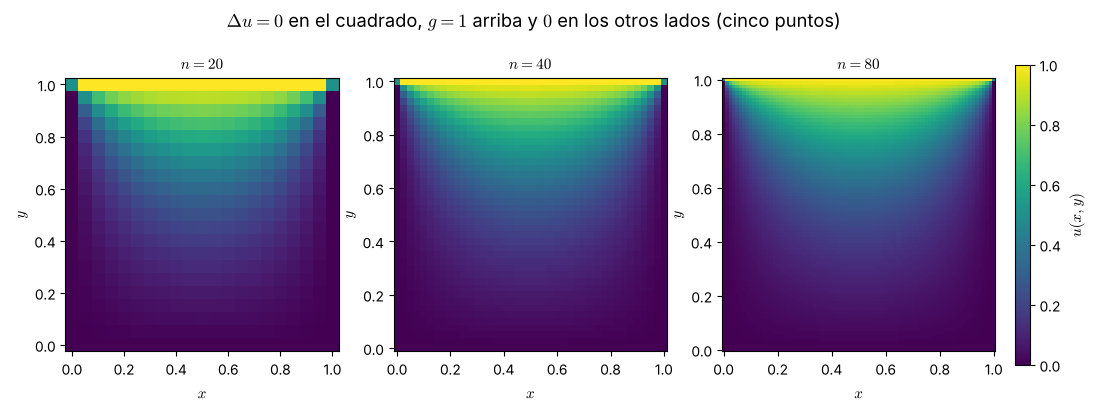


   n    error [1/4,3/4]^2   orden    error rms   orden   error máx.   orden
  20            7.781e-04    1.98    1.115e-03    1.04    7.197e-03    0.00
  40            1.970e-04    2.00    5.435e-04    1.02    7.181e-03    0.00
  80            4.942e-05            2.683e-04            7.180e-03        

(d) n = 20: chequeo_maximo(u) = True
(d) n = 40: chequeo_maximo(u) = True
(d) n = 80: chequeo_maximo(u) = True
error 1 (signo): chequeo_maximo = False, u_min = -0.899
error 2 (sin 1/h^2 en el borde de arriba): chequeo_maximo = True, u en el centro = 0.00063 (debería ser 0.25), máx. interior = 0.0022
residuo de u2 con el b correcto: 3.99e+02 (para u correcta: 4.5e-13)


In [3]:
def ensamblar(n):
    """Matriz rala de -Delta_h (cinco puntos), (n-1)^2 x (n-1)^2, formato CSC."""
    m, h = n - 1, 1 / n
    T = sp.diags([-np.ones(m - 1), 2 * np.ones(m), -np.ones(m - 1)], [-1, 0, 1]) / h ** 2
    Id = sp.identity(m)
    return (sp.kron(Id, T) + sp.kron(T, Id)).tocsc()

def dato_borde(n):
    """G (n+1, n+1): 1 en el lado superior (fila n), 0 en los otros lados, 0.5 en las esquinas de arriba."""
    G = np.zeros((n + 1, n + 1))
    G[n, :] = 1.0
    G[n, 0] = G[n, n] = 0.5
    return G

def rhs(n, G, f=0.0):
    """Lado derecho b (vector de largo (n-1)^2): f + (1/h^2) * (valores de G de los vecinos que están en el borde)."""
    m, h = n - 1, 1 / n
    b = np.array(np.broadcast_to(f, G.shape)[1:-1, 1:-1], dtype=float)
    b[0, :] += G[0, 1:-1] / h ** 2
    b[-1, :] += G[-1, 1:-1] / h ** 2
    b[:, 0] += G[1:-1, 0] / h ** 2
    b[:, -1] += G[1:-1, -1] / h ** 2
    return b.ravel()

def resolver(n, G, f=0.0):
    """Solución u (n+1, n+1) del esquema de cinco puntos para -Delta u = f, u = G en el borde."""
    m = n - 1
    u = G.copy()
    u[1:-1, 1:-1] = spla.spsolve(ensamblar(n), rhs(n, G, f)).reshape(m, m)
    return u

def u_exacta(x, y, K=2000):
    """Suma parcial de la serie de Fourier (k impar < K) para g = 1 arriba, 0 en los otros lados."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    s = np.zeros(np.broadcast(x, y).shape)
    for k in range(1, K, 2):
        cociente = np.exp(k * np.pi * (y - 1)) * (1 - np.exp(-2 * k * np.pi * y)) / (1 - np.exp(-2 * k * np.pi))
        s = s + 4 / (k * np.pi) * np.sin(k * np.pi * x) * cociente
    return s

def chequeo_maximo(u, G, tol=1e-12):
    """True si los valores interiores de u están en [min g, max g] (g: borde sin las esquinas)."""
    g = np.concatenate([G[0, 1:-1], G[-1, 1:-1], G[1:-1, 0], G[1:-1, -1]])
    ui = u[1:-1, 1:-1]
    return bool(ui.min() >= g.min() - tol and ui.max() <= g.max() + tol)

# (a)
n = 20
A = ensamblar(n)
print(f"(a) n = {n}: A es {A.shape[0]} x {A.shape[1]}, simétrica: {abs(A - A.T).max() == 0}, "
      f"máx. no nulos por fila: {np.diff(A.tocsr().indptr).max()}, nnz = {A.nnz} (5 N = {5 * A.shape[0]})")
print(f"    máx |A + laplaciano_2d| = {abs(A + numerico.laplaciano_2d(n - 1, 1 / n)).max():.1e}")

# (b)
soluciones = {}
ns = [20, 40, 80]
fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.9))
for ax, n in zip(axs, ns):
    G = dato_borde(n)
    soluciones[n] = resolver(n, G)
    dif = np.abs(soluciones[n] - numerico.poisson_cinco_puntos(0.0, G, 1 / n)).max()
    print(f"(b) n = {n}: u(centro) = {soluciones[n][n // 2, n // 2]:.15f}; máx |u - poisson_cinco_puntos| = {dif:.1e}")
    im = mapa_color(ax, soluciones[n], f"$n = {n}$", 0, 1)
fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02, label="$u(x,y)$")
fig.suptitle(r"$\Delta u = 0$ en el cuadrado, $g = 1$ arriba y $0$ en los otros lados (cinco puntos)", y=1.02)
plt.show()

# (c)
err_central, err_rms, err_max = {}, {}, {}
for n in ns:
    x = np.linspace(0, 1, n + 1)
    X, Y = np.meshgrid(x, x)
    E = np.abs(soluciones[n] - u_exacta(X, Y, K=2000))[1:-1, 1:-1]       # error en los nodos interiores
    XI, YI = X[1:-1, 1:-1], Y[1:-1, 1:-1]
    lejos = (XI >= 0.25 - 1e-12) & (XI <= 0.75 + 1e-12) & (YI >= 0.25 - 1e-12) & (YI <= 0.75 + 1e-12)
    err_central[n], err_rms[n], err_max[n] = E[lejos].max(), np.sqrt(np.mean(E ** 2)), E.max()
print(f"\n{'n':>4} {'error [1/4,3/4]^2':>20} {'orden':>7} {'error rms':>12} {'orden':>7} {'error máx.':>12} {'orden':>7}")
for k, n in enumerate(ns):
    ord_ = lambda e: f"{np.log2(e[n] / e[2 * n]):7.2f}" if n != 80 else f"{'':>7}"
    print(f"{n:4d} {err_central[n]:20.3e} {ord_(err_central)} {err_rms[n]:12.3e} {ord_(err_rms)} {err_max[n]:12.3e} {ord_(err_max)}")

# (d)
print()
for n in ns:
    print(f"(d) n = {n}: chequeo_maximo(u) = {chequeo_maximo(soluciones[n], dato_borde(n))}")
n = 20; G = dato_borde(n); A = ensamblar(n); b = rhs(n, G)
m, h = n - 1, 1 / n
u1 = G.copy(); u1[1:-1, 1:-1] = spla.spsolve(-A, b).reshape(m, m)                  # error 1: signo
b2 = b.copy().reshape(m, m)
b2[-1, :] -= G[-1, 1:-1] / h ** 2; b2[-1, :] += G[-1, 1:-1]                           # error 2: la fila de arriba sin 1/h^2
u2 = G.copy(); u2[1:-1, 1:-1] = spla.spsolve(A, b2.ravel()).reshape(m, m)
print(f"error 1 (signo): chequeo_maximo = {chequeo_maximo(u1, G)}, u_min = {u1[1:-1, 1:-1].min():.3f}")
print(f"error 2 (sin 1/h^2 en el borde de arriba): chequeo_maximo = {chequeo_maximo(u2, G)}, u en el centro = {u2[n // 2, n // 2]:.5f} (debería ser 0.25), "
      f"máx. interior = {u2[1:-1, 1:-1].max():.4f}")
print(f"residuo de u2 con el b correcto: {np.abs(A @ u2[1:-1, 1:-1].ravel() - b).max():.2e} (para u correcta: {np.abs(A @ soluciones[20][1:-1, 1:-1].ravel() - b).max():.1e})")

In [4]:
# Verificación
assert set(soluciones) == {20, 40, 80} and all(soluciones[n].shape == (n + 1, n + 1) for n in soluciones)
assert abs(ensamblar(20) - ensamblar(20).T).max() == 0 and ensamblar(20).nnz <= 5 * 19 ** 2
assert abs(ensamblar(20) + numerico.laplaciano_2d(19, 1 / 20)).max() < 1e-9, "ensamblar no coincide con -laplaciano_2d"
for n in (20, 40, 80):
    assert np.abs(soluciones[n] - numerico.poisson_cinco_puntos(0.0, dato_borde(n), 1 / n)).max() < 1e-9, f"n = {n}: no coincide con poisson_cinco_puntos"
    assert abs(soluciones[n][n // 2, n // 2] - 0.25) < 1e-10, "en el centro u debería valer 1/4 (simetría)"
assert abs(u_exacta(0.5, 0.5, K=2000) - 0.25) < 1e-6, "u_exacta(1/2, 1/2) debería ser 1/4"
o1, o2 = np.log2(err_central[20] / err_central[40]), np.log2(err_central[40] / err_central[80])
assert 1.8 < o1 < 2.3 and 1.8 < o2 < 2.3, f"orden observado {o1:.2f}, {o2:.2f}: se esperaba ~2"
assert err_central[20] < 3e-3 and 5e-3 < err_max[80] < 1e-2, "errores fuera de lo esperado"
assert chequeo_maximo(soluciones[20], dato_borde(20)) and not chequeo_maximo(-soluciones[20], dato_borde(20))
print("cinco puntos: OK")

cinco puntos: OK

**Para el docente.** Errores en los nodos del $[1/4,3/4]^2$: $7.78\times10^{-4}$, $1.97\times10^{-4}$, $4.94\times10^{-5}$ ($n = 20, 40, 80$; órdenes $1.98$ y $2.00$); error cuadrático medio $1.12\times10^{-3}$, $5.4\times10^{-4}$, $2.7\times10^{-4}$ (orden $1.04$, $1.02$: el error cerca de las esquinas de arriba, donde el dato salta, decae como $h$); error máximo $7.2\times10^{-3}$ en los tres casos, en los nodos vecinos a las esquinas de arriba, como el nodo $(n-1, 1)$: **no converge** (es un comportamiento genuino, no un problema de truncar la serie: con $K = 6000$ da lo mismo; el esquema no usa el valor de $g$ en la esquina, y $u$ no es suave ahí). Si un estudiante mide solo el máximo global va a concluir "orden 0"; que lo discutan (es lo que pide el markdown). Con $n=20$ el centro vale $0.25$ hasta $10^{-16}$ y hasta $10^{-14}$ con $n=80$. Errores provocados: con el signo cambiado $u_{\min} = -0.90$ y el chequeo falla; sin el $1/h^2$ en el lado superior, $u$ en el centro vale $6\times10^{-4}$ (todo queda en $[0, 0.002]$) y el chequeo **no** lo detecta; el residuo con el $b$ correcto es $4\times10^2$ (contra $10^{-12}$ de la buena). Errores típicos: ordenar las incógnitas por columnas y no darse cuenta al hacer `.reshape`; confundir el orden de las incógnitas (por filas o por columnas) entre `ensamblar` y el `reshape` de la solución: como el dato no es simétrico en $x\leftrightarrow y$, el mapa sale traspuesto (lado de arriba en el lado derecho); olvidar el $1/h^2$ en `b` (mapa casi nulo); usar `np.linalg.solve` con `toarray()` en $n=80$ (funciona pero tarda $2$ s). Tiempo: 30 minutos.

## 2. Cuánto cuesta: matriz densa contra matriz rala

El sistema tiene $N = (n-1)^2 \approx n^2$ incógnitas. Hay dos maneras de guardar $A$ y de resolverla:

* **Densa** (`A.toarray()` y `np.linalg.solve`): la matriz guarda $N^2 \approx n^4$ números (8 bytes cada uno) y la eliminación gaussiana (o Cholesky) cuesta $\sim N^3 \approx n^6$ operaciones. Duplicar $n$ multiplica la memoria por $16$ y el tiempo por $64$.
* **Rala** (`scipy.sparse`, `spsolve`): $A$ tiene $\approx 5N$ no nulos, así que guardarla cuesta $O(n^2)$: las tres listas del formato CSC son `data` (los valores), `indices` (las filas) e `indptr` (dónde empieza cada columna), y su tamaño total es `A.data.nbytes + A.indices.nbytes + A.indptr.nbytes`. `spsolve` factoriza $A = LU$ reordenando las incógnitas para que $L$ y $U$ tengan pocos no nulos (el "**fill-in**"): con un buen reordenamiento (*nested dissection*) el costo para la grilla 2D es $O(N^{3/2}) = O(n^3)$ en tiempo y $O(N\log N)$ en memoria (con el reordenamiento por defecto de SuperLU, `COLAMD`, es algo peor pero del mismo orden). Podés ver el fill-in directamente con `lu = spla.splu(A)`: la cantidad de no nulos de los factores es `lu.L.nnz + lu.U.nnz`. Otra ventaja de factorizar una sola vez con `splu`: `lu.solve(b)` resuelve luego cualquier lado derecho nuevo casi gratis (útil cuando el dato cambia y la matriz no).

**Cómo medir.** El tiempo con `time.perf_counter()` (para tamaños chicos repetí la medición y tomá el mínimo: los milisegundos son ruidosos); la memoria de la matriz densa con `Ad.nbytes`, la de la rala con la suma de arriba. Para ver el **exponente** graficá en escala log-log contra $n$ y ajustá una recta con `np.polyfit(np.log(n), np.log(t), 1)`: la pendiente es el exponente. **Qué esperar:** memoria densa con pendiente $\approx4$ y rala $\approx2$ (un poco menos, porque $N = (n-1)^2$ y no $n^2$); tiempo denso con pendiente entre $4.5$ y $6$ (la teoría dice $6$, pero con tamaños chicos manda el costo de la librería optimizada, y aparecen efectos de caché) y tiempo ralo con pendiente entre $2$ y $3$. Los números absolutos dependen de la computadora; **los exponentes no**.

### Tarea 2: Tiempo y memoria: denso contra ralo

Con `ensamblar(n)` de la Tarea 1 y el lado derecho `rhs(n, dato_borde(n))`:

**(a)** Para $n \in \{10, 20, 30, 40, 60, 80\}$ medí el tiempo de resolver con matriz densa (`np.linalg.solve(A.toarray(), b)`) y la memoria de la matriz densa. Guardalos en los arrays `t_denso` y `mem_denso` (bytes). No pases de $n = 80$ (la matriz ya ocupa $300$ MB).

**(b)** Para $n \in \{10, 20, 40, 80, 160, 320, 480\}$ medí el tiempo de `spsolve`, la memoria de la matriz rala (en bytes) y el fill-in (`nnz` de $L$ más $U$ por `splu`, dividido por `A.nnz`). Guardalos en `t_ralo`, `mem_ralo` y `fill`.

**(c)** Graficá en log-log el tiempo y la memoria contra $n$ (dos paneles, denso y ralo en cada uno) y ajustá los exponentes: `exp_t_denso`, `exp_t_ralo`, `exp_mem_denso`, `exp_mem_ralo` (para el tiempo ajustá solo con los $n\ge 40$: los tiempos de $n$ chico son ruido).

**(d)** Con los exponentes ajustados (y la memoria a $n = 80$ como referencia) estimá: ¿qué $n$ máximo se puede resolver con matriz densa en $16$ GB de memoria? ¿Y en cuánto tiempo se resolvería $n = 1000$ (un millón de incógnitas) con matriz rala, si la memoria no fuera problema? Escribí las cuentas.

**Qué se espera.** Exponentes de memoria $\approx 4$ (denso) y $\approx 2$ (ralo); de tiempo entre $4.5$ y $6$ (denso) y entre $2$ y $3$ (ralo). A $n=80$ el denso pesa $\approx 300$ MB y el ralo $\approx 0.4$ MB (un factor $\approx 800$); el fill-in crece lentamente con $n$ (de $\approx3$ veces los no nulos de $A$ en $n=10$ a $\approx24$ en $n=480$: $L$ y $U$ tienen más no nulos que $A$, pero siguen siendo $O(N\log N)$). El $n$ máximo denso es del orden de $200$; el ralo hace $n = 1000$ en unas decenas de segundos.

    n        N |  t denso [s]    mem denso |   t ralo [s]   mem ralo  fill-in
   10       81 |       0.0000      0.05 MB |       0.0001    0.00 MB      3.1
   20      361 |       0.6241      1.04 MB |       0.0006    0.02 MB      5.3
   30      841 |       0.0389      5.66 MB | 
   40     1521 |       0.4294     18.51 MB |       0.0025    0.10 MB      8.2
   60     3481 |       4.1509     96.94 MB | 
   80     6241 |      14.4775    311.60 MB |       0.0365    0.40 MB     11.9
  160    25281 |                           |       0.3822    1.61 MB     16.3
  320   101761 |                           |       2.1138    6.50 MB     21.2
  480   229441 |                           |       5.1413   14.66 MB     24.0

exponentes ajustados: tiempo denso 5.11, tiempo ralo 3.06; memoria densa 4.17, memoria rala 2.07


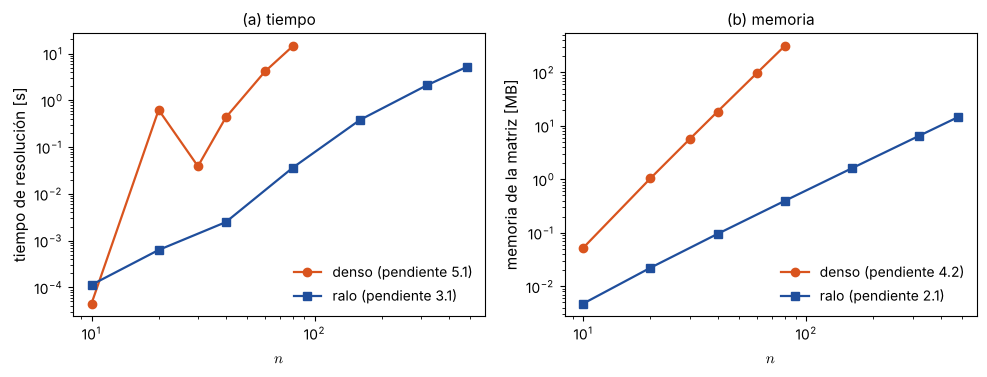

(d) memoria densa a n = 80: 312 MB; con 16 GB: n_max ~ 80 (16e9 / 3.12e+08)^(1/4.2) = 206
    ralo, n = 1000: t ~ t(480) (1000/480)^3.06 = 49 s; memoria de A ~ 64 MB


In [5]:
def mejor_tiempo(f, reps):
    """Mínimo de reps mediciones del tiempo de f() (segundos)."""
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); f(); ts.append(time.perf_counter() - t0)
    return min(ts)

ns_d = [10, 20, 30, 40, 60, 80]
ns_r = [10, 20, 40, 80, 160, 320, 480]
t_denso, mem_denso, t_ralo, mem_ralo, fill = [], [], [], [], []
for n in ns_d:
    A = ensamblar(n); b = rhs(n, dato_borde(n)); Ad = A.toarray()
    t_denso.append(mejor_tiempo(lambda: np.linalg.solve(Ad, b), 3 if n < 60 else 1))
    mem_denso.append(Ad.nbytes)
for n in ns_r:
    A = ensamblar(n); b = rhs(n, dato_borde(n))
    t_ralo.append(mejor_tiempo(lambda: spla.spsolve(A, b), 5 if n < 160 else 1))
    mem_ralo.append(A.data.nbytes + A.indices.nbytes + A.indptr.nbytes)
    lu = spla.splu(A); fill.append((lu.L.nnz + lu.U.nnz) / A.nnz)
t_denso, mem_denso, t_ralo, mem_ralo, fill = map(np.array, (t_denso, mem_denso, t_ralo, mem_ralo, fill))

def exponente(n, y, desde=0):
    n, y = np.array(n), np.array(y); k = n >= desde
    return np.polyfit(np.log(n[k]), np.log(y[k]), 1)[0]

exp_t_denso, exp_t_ralo = exponente(ns_d, t_denso, 40), exponente(ns_r, t_ralo, 40)
exp_mem_denso, exp_mem_ralo = exponente(ns_d, mem_denso), exponente(ns_r, mem_ralo)

print(f"{'n':>5} {'N':>8} | {'t denso [s]':>12} {'mem denso':>12} | {'t ralo [s]':>12} {'mem ralo':>10} {'fill-in':>8}")
for n in sorted(set(ns_d) | set(ns_r)):
    fila = f"{n:5d} {(n - 1) ** 2:8d} | "
    fila += f"{t_denso[ns_d.index(n)]:12.4f} {mem_denso[ns_d.index(n)] / 1e6:9.2f} MB | " if n in ns_d else f"{'':>12} {'':>12} | "
    fila += f"{t_ralo[ns_r.index(n)]:12.4f} {mem_ralo[ns_r.index(n)] / 1e6:7.2f} MB {fill[ns_r.index(n)]:8.1f}" if n in ns_r else ""
    print(fila)
print(f"\nexponentes ajustados: tiempo denso {exp_t_denso:.2f}, tiempo ralo {exp_t_ralo:.2f}; memoria densa {exp_mem_denso:.2f}, memoria rala {exp_mem_ralo:.2f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 3.9))
axs[0].loglog(ns_d, t_denso, "o-", color=COLORES["modelo"], label=f"denso (pendiente {exp_t_denso:.1f})")
axs[0].loglog(ns_r, t_ralo, "s-", color=COLORES["traj"], label=f"ralo (pendiente {exp_t_ralo:.1f})")
axs[0].set_xlabel("$n$"); axs[0].set_ylabel("tiempo de resolución [s]"); axs[0].legend(); axs[0].set_title("(a) tiempo")
axs[1].loglog(ns_d, mem_denso / 1e6, "o-", color=COLORES["modelo"], label=f"denso (pendiente {exp_mem_denso:.1f})")
axs[1].loglog(ns_r, mem_ralo / 1e6, "s-", color=COLORES["traj"], label=f"ralo (pendiente {exp_mem_ralo:.1f})")
axs[1].set_xlabel("$n$"); axs[1].set_ylabel("memoria de la matriz [MB]"); axs[1].legend(); axs[1].set_title("(b) memoria")
fig.tight_layout(); plt.show()

# (d)
mem80 = mem_denso[ns_d.index(80)]
n_max_denso = 80 * (16e9 / mem80) ** (1 / exp_mem_denso)
t1000 = t_ralo[ns_r.index(480)] * (1000 / 480) ** exp_t_ralo
print(f"(d) memoria densa a n = 80: {mem80 / 1e6:.0f} MB; con 16 GB: n_max ~ 80 (16e9 / {mem80:.2e})^(1/{exp_mem_denso:.1f}) = {n_max_denso:.0f}")
print(f"    ralo, n = 1000: t ~ t(480) (1000/480)^{exp_t_ralo:.2f} = {t1000:.0f} s; memoria de A ~ {mem_ralo[-1] * (1000 / 480) ** 2 / 1e6:.0f} MB")

In [6]:
# Verificación
assert abs(exp_mem_denso - 4) < 0.3 and abs(exp_mem_ralo - 2) < 0.15, "los exponentes de memoria deberían ser 4 y 2"
assert 4.0 < exp_t_denso < 6.5, f"exponente de tiempo denso {exp_t_denso:.2f}: se esperaba entre 4.5 y 6"
assert 1.8 < exp_t_ralo < 3.3, f"exponente de tiempo ralo {exp_t_ralo:.2f}: se esperaba entre 2 y 3"
assert mem_denso[-1] / mem_ralo[ns_r.index(80)] > 300, "a n = 80 el denso debería pesar cientos de veces más que el ralo"
print("costo denso/ralo: OK")

costo denso/ralo: OK


**Para el docente.** Resultados en la máquina de referencia (dos núcleos): a $n=80$ el denso tarda $1.6$–$2.0$ s y pesa $312$ MB; el ralo $11$ ms y $0.40$ MB (factor $780$ en memoria, $150$ en tiempo). Exponentes de tiempo: denso $5.3$–$5.8$ (ajustado con $n=40,60,80$; varía entre corridas, porque hay pocos puntos y BLAS es multihilo), ralo $2.6$–$2.7$; de memoria: $4.17$ y $2.07$ (no $4$ y $2$ exactos porque $N=(n-1)^2$). Fill-in: $3.1$ ($n=10$), $8.2$ ($n=40$), $16$ ($n=160$), $24$ ($n=480$). $n_{\max}$ denso en $16$ GB: $\approx 205$; $n = 1000$ ralo: $\approx 11$ s y $64$ MB para $A$ (los factores son $\sim30$ veces más: $\sim2$ GB, buen punto para discutir que "la memoria no fuera problema" no es del todo cierto). Errores típicos: medir el tiempo de `A.toarray()` junto con el de la resolución; medir una sola vez con $n$ chico (ruido: el denso a $n=10$ puede salir *más rápido* que el ralo, y es correcto: la sobrecarga de `spsolve`); usar `sys.getsizeof` para la memoria (da el tamaño del objeto Python, no de los arrays); ajustar la pendiente con todos los puntos (los de $n$ chico dan pendientes falsas). Tiempo: 15 minutos.

## 3. Resolver jugando: Monte Carlo

### El juego y el estimador

Desde un nodo interior $p = (i,j)$ el jugador se mueve a uno de sus cuatro vecinos con probabilidad $\tfrac14$, y repite hasta que toca un nodo del borde $q$; ahí cobra $g(q)$. Sea $u(p)$ el **valor esperado del pago** cuando se parte de $p$. Condicionando en el primer paso (cada vecino con probabilidad $\frac14$, y desde el vecino el juego empieza de nuevo) resulta

$$u(p) = \frac14\sum_{p'\sim p} u(p'),\qquad u(q) = g(q)\ \ (q\in\text{borde}),$$

que es **exactamente** la ecuación de promedios del esquema de cinco puntos. Como el sistema lineal tiene solución única, el valor esperado del juego es la solución del esquema de cinco puntos, *sin ningún error de discretización aparte* (el error de discretización, $O(h^2)$, es el del esquema respecto de la ecuación continua, y es igual en los dos métodos).

Para estimar $u(p)$ se simulan $M$ partidas independientes, cada una con pago $X_1,\dots,X_M$, y se promedia:

$$\hat u_M(p) = \frac1M\sum_{m=1}^M X_m,\qquad \mathbb E[\hat u_M] = u(p),\qquad \operatorname{sd}(\hat u_M) = \frac{\sigma(p)}{\sqrt M},\quad \sigma^2 = \operatorname{Var}(X).$$

El estimador no tiene sesgo y su **error estadístico cae como $M^{-1/2}$** (ley de los grandes números y teorema central del límite): para dividir el error por $10$ hay que simular $100$ veces más partidas. La $\sigma$ se estima con el desvío muestral de los pagos, y $\hat\sigma/\sqrt M$ (el "error estándar") es el error de la estimación *que podés calcular sin conocer la solución*. Cuando el pago es $0$ o $1$ (como en nuestro problema, con $g\in\{0,1\}$) $X$ es una Bernoulli de parámetro $u$ y $\sigma = \sqrt{u(1-u)}\le\frac12$: $u$ es la **probabilidad** de salir por el lado de arriba.

### Cuánto cuesta una partida

Un paseo al azar tarda $\sim n^2$ pasos en llegar al borde (para desplazarse una distancia $L$ a saltos de tamaño $h$ hacen falta $\sim (L/h)^2$ pasos): en el cuadrado, desde el centro, el número esperado de pasos es $\approx 0.29\,n^2$ (lo vas a medir en la Tarea 4 y a explicar en la Tarea 6). Entonces:

* estimar **un** valor $u(p)$ con error estadístico $\varepsilon$ cuesta $M = (\sigma/\varepsilon)^2$ partidas de $\approx 0.29\,n^2$ pasos cada una: $\sim \sigma^2 n^2/\varepsilon^2$ pasos;
* estimar **toda** la función en los $N\approx n^2$ nodos cuesta $N$ veces eso, $\sim n^4/\varepsilon^2$; y para que el error *total* sea comparable con el de discretización ($\sim h^2 = n^{-2}$), $\varepsilon\sim n^{-2}$: $\sim n^{8}$. Mientras que el sistema ralo cuesta $\sim n^3$ y da **todos** los valores con precisión de máquina.

Entonces, en 2D, **el sistema lineal ralo le gana por muchísimo a Monte Carlo**. ¿Para qué sirve Monte Carlo, entonces? Para dos cosas: si sólo querés el valor en *un* punto (con un error modesto, digamos $10^{-2}$), y sobre todo si la dimensión es alta. La grilla en dimensión $d$ tiene $N = n^d$ nodos: con $n = 20$ y $d = 10$, $N \approx 10^{13}$ y ni siquiera podés guardar un vector con una incógnita por nodo. Pero el juego en $d$ dimensiones es igual de simple (un paso es elegir una de las $2d$ direcciones), el **error estadístico $\sigma/\sqrt M$ no depende de $d$** y el costo por partida crece apenas como una potencia de $d$. Ese es el sentido en que Monte Carlo "no sufre la maldición de la dimensión". En la Tarea 4 lo vas a ver con un problema de dimensión $d$ cuya respuesta exacta se conoce por simetría.

**Cómo programarlo.** Simular una partida por vez con un bucle de Python es lento; conviene simular **las $M$ partidas a la vez** con arrays de `numpy`: un vector con la posición (`ii`, `jj`) de cada jugador, otro con quién sigue jugando, y en cada paso se mueven sólo los que siguen activos (un jugador que llega al borde cobra y sale). El número de iteraciones del bucle `while` es el del paseo más largo, unos cientos de pasos. Contá también el **costo** en "pasos de jugador" (suma de los largos de las partidas): es una medida del trabajo que no depende de la computadora.

### Tarea 3: Monte Carlo: `valor_mc`, mapas y error contra $M$

Con el mismo problema de la Tarea 1 ($g=1$ arriba, $0$ en los otros lados), $n = 20$ y la solución de cinco puntos `soluciones[20]` como referencia:

**(a)** Escribí `valor_mc(i, j, M, G, rng=None)`: simula $M$ partidas a la vez desde el nodo interior $(i,j)$ (los cuatro movimientos con igual probabilidad, hasta tocar el borde) y devuelve la tripla `(media, error_estandar, pasos)` con la media de los pagos, el error estándar `std(ddof=1)/sqrt(M)` y el total de pasos de jugador (suma de los largos de las $M$ partidas). Usá un generador `rng = np.random.default_rng(semilla)` para que los resultados se puedan repetir.

**(b)** Hacé un mapa de $u$ por Monte Carlo (en los $19^2$ nodos interiores) para $M = 10, 100, 1000$ y compará con el de cinco puntos: una figura de cuatro paneles (los tres MC y la referencia, misma escala). Imprimí, para cada $M$, el error máximo y el error cuadrático medio contra la referencia, y guardá los mapas en `U_mc[M]` (arrays $(n+1)\times(n+1)$ con el borde igual a $G$).

**(c)** *El error contra $M$.* En el nodo $(i,j) = (15, 10)$ (o sea $(x,y) = (0.5, 0.75)$) medí el error cuadrático medio de $\hat u_M$ respecto de la referencia, con $M \in \{10, 30, 100, 300, 1000, 3000, 10^4\}$, repitiendo la estimación $R = 100$ veces con semillas distintas para cada $M$ (el error de *una* estimación es una variable aleatoria: lo que tiene sentido graficar es su desvío típico). Guardá los errores en `rms[M]`. Graficá en log-log `rms` contra $M$ junto con la recta teórica $\sigma/\sqrt M$, $\sigma = \sqrt{u(1-u)}$, y ajustá la pendiente (`pend`).

**(d)** Con la misma corrida de (c) medí el **costo** de una llamada en función de $M$ (pasos de jugador y tiempo) y comprobá que crece linealmente con $M$; calculá los pasos por partida.

**Qué se espera.** (b) los tres mapas son cada vez menos ruidosos; con $M=10$ el error máximo es del orden de $0.3$, con $M=100$ de $0.1$, con $M=1000$ de $0.04$ (el máximo sobre $361$ nodos crece por encima del típico; el error cuadrático medio baja como $M^{-1/2}$). (c) pendiente $-0.5\pm0.1$, con la curva medida sobre la teórica (el $\sigma$ del pago es $\approx 0.5$); $u(15,10)\approx0.54$. (d) los pasos de jugador crecen linealmente con $M$ y cada partida dura del orden de $n^2$ pasos (unos $90$ desde ese nodo, que está más cerca del borde que el centro; lo que importa es que sea $O(n^2)$ y que no dependa de $M$); el tiempo de pared crece más lento que $M$ para $M$ chico, porque cada iteración del bucle tiene un costo fijo de Python.

(b) M =   10: error máximo 0.368, error cuadrático medio 0.106 (0.5/sqrt(M) = 0.158);  5.3 s para los 361 nodos


(b) M =  100: error máximo 0.104, error cuadrático medio 0.034 (0.5/sqrt(M) = 0.050);  8.1 s para los 361 nodos


(b) M = 1000: error máximo 0.043, error cuadrático medio 0.011 (0.5/sqrt(M) = 0.016);  13.9 s para los 361 nodos


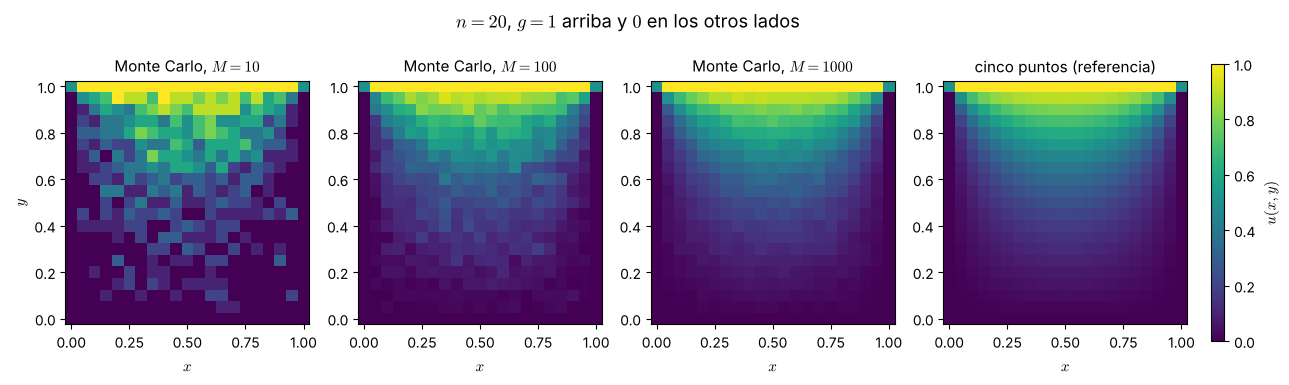


(c) u_5p(15,10) = 0.5398, sigma = sqrt(u(1-u)) = 0.498; pendiente ajustada: -0.500 (teoría -0.5)
    M =     10: error rms 0.1642  (teoría sigma/sqrt(M) = 0.1576)
    M =     30: error rms 0.0862  (teoría sigma/sqrt(M) = 0.0910)
    M =    100: error rms 0.0492  (teoría sigma/sqrt(M) = 0.0498)
    M =    300: error rms 0.0309  (teoría sigma/sqrt(M) = 0.0288)
    M =   1000: error rms 0.0164  (teoría sigma/sqrt(M) = 0.0158)
    M =   3000: error rms 0.0088  (teoría sigma/sqrt(M) = 0.0091)
    M =  10000: error rms 0.0050  (teoría sigma/sqrt(M) = 0.0050)


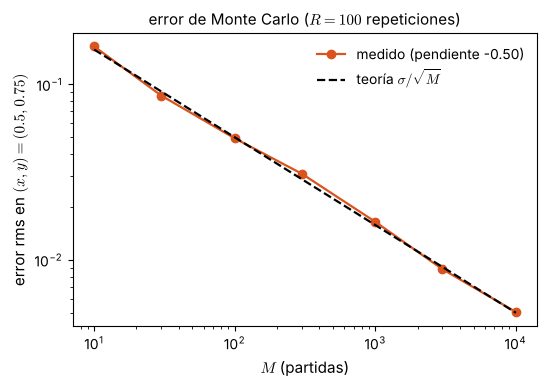


(d)      M   pasos de jugador  pasos por partida  tiempo [ms]
        10                869               86.9         11.5
        30               2743               91.4         16.0
       100               9181               91.8         20.4
       300              27404               91.3         23.3
      1000              91825               91.8         25.9
      3000             275351               91.8         33.1
     10000             916063               91.6         63.2


In [7]:
def valor_mc(i, j, M, G, rng=None):
    """Simula M partidas desde el nodo interior (i, j) con pago G en el borde.
    Devuelve (media, error_estandar, pasos_totales)."""
    rng = np.random.default_rng() if rng is None else rng
    n = G.shape[0] - 1
    ii, jj = np.full(M, i), np.full(M, j)
    pago = np.zeros(M)
    activo = np.ones(M, dtype=bool)
    pasos = 0
    while activo.any():
        k = np.flatnonzero(activo)                      # los que siguen jugando
        pasos += k.size
        d = rng.integers(4, size=k.size)                # 0: abajo, 1: arriba, 2: izquierda, 3: derecha
        ii[k] += (d == 0).astype(int) - (d == 1)
        jj[k] += (d == 2).astype(int) - (d == 3)
        llego = (ii[k] == 0) | (ii[k] == n) | (jj[k] == 0) | (jj[k] == n)
        kf = k[llego]
        pago[kf] = G[ii[kf], jj[kf]]                    # cobra y sale
        activo[kf] = False
    return pago.mean(), pago.std(ddof=1) / np.sqrt(M), pasos

n = 20
G = dato_borde(n)
u_ref = soluciones[20]
rng = np.random.default_rng(0)

# (b)
U_mc = {}
for M in [10, 100, 1000]:
    U = G.copy()
    t0 = time.perf_counter()
    for i in range(1, n):
        for j in range(1, n):
            U[i, j] = valor_mc(i, j, M, G, rng)[0]
    U_mc[M] = U
    err = (U - u_ref)[1:-1, 1:-1]
    print(f"(b) M = {M:4d}: error máximo {np.abs(err).max():.3f}, error cuadrático medio {np.sqrt(np.mean(err ** 2)):.3f} "
          f"(0.5/sqrt(M) = {0.5 / np.sqrt(M):.3f});  {time.perf_counter() - t0:.1f} s para los {(n - 1) ** 2} nodos")
fig, axs = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, M in zip(axs[:3], U_mc):
    mapa_color(ax, U_mc[M], f"Monte Carlo, $M = {M}$", 0, 1)
im = mapa_color(axs[3], u_ref, "cinco puntos (referencia)", 0, 1)
fig.colorbar(im, ax=axs, fraction=0.015, pad=0.02, label="$u(x,y)$")
for ax in axs[1:]:
    ax.set_ylabel("")
fig.suptitle("$n = 20$, $g = 1$ arriba y $0$ en los otros lados", y=1.03)
plt.show()

# (c)
Ms = [10, 30, 100, 300, 1000, 3000, 10000]
i0, j0, R = 15, 10, 100
rms = {}
costo = {}
for M in Ms:
    t0 = time.perf_counter()
    salidas = [valor_mc(i0, j0, M, G, np.random.default_rng(1000 * M + r)) for r in range(R)]
    est = np.array([s[0] for s in salidas])
    rms[M] = np.sqrt(np.mean((est - u_ref[i0, j0]) ** 2))
    costo[M] = (np.mean([s[2] for s in salidas]), (time.perf_counter() - t0) / R)
pend = np.polyfit(np.log(Ms), np.log([rms[M] for M in Ms]), 1)[0]
sigma = np.sqrt(u_ref[i0, j0] * (1 - u_ref[i0, j0]))
print(f"\n(c) u_5p({i0},{j0}) = {u_ref[i0, j0]:.4f}, sigma = sqrt(u(1-u)) = {sigma:.3f}; pendiente ajustada: {pend:.3f} (teoría -0.5)")
for M in Ms:
    print(f"    M = {M:6d}: error rms {rms[M]:.4f}  (teoría sigma/sqrt(M) = {sigma / np.sqrt(M):.4f})")
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.loglog(Ms, [rms[M] for M in Ms], "o-", color=COLORES["modelo"], label=f"medido (pendiente {pend:.2f})")
ax.loglog(Ms, sigma / np.sqrt(Ms), "--", color="black", label=r"teoría $\sigma/\sqrt{M}$")
ax.set_xlabel("$M$ (partidas)"); ax.set_ylabel(f"error rms en $(x, y) = ({j0 / n}, {i0 / n})$"); ax.legend()
ax.set_title(f"error de Monte Carlo ($R = {R}$ repeticiones)")
fig.tight_layout(); plt.show()

# (d)
print(f"\n(d) {'M':>6} {'pasos de jugador':>18} {'pasos por partida':>18} {'tiempo [ms]':>12}")
for M in Ms:
    print(f"    {M:6d} {costo[M][0]:18.0f} {costo[M][0] / M:18.1f} {1000 * costo[M][1]:12.1f}")

In [8]:
# Verificación
m_, e_, p_ = valor_mc(10, 10, 4000, dato_borde(20), np.random.default_rng(5))
assert abs(m_ - 0.25) < 4 * e_ + 1e-12 and p_ > 4000, f"valor_mc en el centro: {m_:.3f} +- {e_:.3f} (debería ser 0.25)"
assert set(U_mc) == {10, 100, 1000}
e = [np.sqrt(np.mean((U_mc[M] - u_ref)[1:-1, 1:-1] ** 2)) for M in (10, 100, 1000)]
assert e[0] > e[1] > e[2] and 0.5 < e[0] / e[2] / 10 < 2, f"errores {e}: el cociente entre M = 10 y M = 1000 debería ser ~10"
assert -0.62 < pend < -0.38, f"pendiente {pend:.2f}: se esperaba -0.5"
print("Monte Carlo: OK")

Monte Carlo: OK


**Para el docente.** $u(15,10) = 0.5398$, $\sigma = 0.498$. Errores de los mapas contra cinco puntos: $M = 10$: máximo $0.37$, cuadrático medio $0.106$; $M=100$: $0.10$ y $0.034$; $M=1000$: $0.043$ y $0.011$ (ECM $\approx 0.68\times\sigma/\sqrt M$ en promedio sobre nodos porque $\sigma(p) = \sqrt{u(1-u)}$ es menor que $0.5$ en casi todo el cuadrado). Error contra $M$ ($R=100$): $0.164, 0.086, 0.049, 0.031, 0.0164, 0.0088, 0.0050$ para $M = 10,\dots,10^4$; pendiente $-0.500$ (con $R=100$ el error de la pendiente es de $\pm0.03$: si a algún estudiante le da $-0.45$ o $-0.55$ es normal; con $R=10$ ya no). Costo: $\approx 92$ pasos por partida desde $(15,10)$ (linealidad exacta en $M$: $869, 9181, 91825, 916063$ pasos para $M = 10, 100, 1000, 10^4$); el tiempo de pared va de $7$ ms ($M=10$) a $34$ ms ($M = 10^4$): crece lento porque domina el bucle `while` (unas cientos de iteraciones con arrays chicos). Errores típicos: ir actualizando `ii`, `jj` para todos los jugadores (también los que ya terminaron: siguen caminando y cobran de nuevo, o se salen de la grilla con `IndexError`); calcular el error de *una* corrida y llamarlo "el error" (sale ruidoso y la pendiente da cualquier cosa); usar la misma semilla para todos los $M$ y $r$; usar `pago.std()` sin `ddof=1` (diferencia despreciable); simular partidas de a una con un bucle de Python ($M=10^4$ tarda minutos). Tiempo: 35 minutos.

### Comparar costos, y qué pasa en dimensión alta

Las dos tareas que siguen ponen números a la discusión de arriba. Primero, **cuánto tarda un paseo**: si el paseo dura $\sim c\,n^2$ pasos, estimar un valor con error $\varepsilon$ cuesta $\sim(\sigma/\varepsilon)^2\,c\,n^2$ pasos, y hay que ver cuánto vale $c$. Segundo, **cuánto cuestan los dos métodos para la misma respuesta**: tomamos un solo nodo, exigimos un error estadístico de $\varepsilon = 0.01$ (dos decimales) y comparamos el tiempo de Monte Carlo *en ese nodo* con el tiempo del sistema ralo, que da *todos los nodos* con error de máquina. Tercero, la **dimensión**: en el cubo $[0,n]^d$ (con $n = 20$), un jugador que parte del centro elige en cada paso una de las $d$ coordenadas y un signo, y termina al tocar una cara. Si el pago es $1$ en la cara $x_d = n$ y $0$ en las otras $2d-1$, por simetría el valor esperado en el centro es exactamente $\frac{1}{2d}$ (las $2d$ caras son equiprobables): tenemos la respuesta exacta en cualquier dimensión, y podemos ver el error de Monte Carlo sin que haga falta ninguna grilla.

### Tarea 4: Costo de Monte Carlo contra cinco puntos, y dimensión

Usá `valor_mc` (Tarea 3) y `resolver` (Tarea 1).

**(a)** *Duración de un paseo.* Para $n = 10, 20, 40, 80$ estimá el número medio de pasos que dura una partida que sale del centro del cuadrado ($M = 400$ partidas; usá el tercer valor que devuelve `valor_mc`, dividido por $M$). Ajustá el exponente en $n$ (`exp_T`) y el coeficiente $c = \bar T / n^2$ (`c_T`).

**(b)** *Mismo error, dos costos.* Para $n = 20, 40, 80$ y el nodo $(i,j) = (3n/4,\ n/2)$ (o sea $(x,y) = (0.5, 0.75)$): tomá $\sigma = \sqrt{u(1-u)}$ con $u$ la solución de cinco puntos en ese nodo, elegí $M = \lceil \sigma^2/\varepsilon^2\rceil$ para $\varepsilon = 0.01$ y medí: el tiempo de `resolver(n, G)` (todos los nodos, error de máquina respecto del sistema), el tiempo de `valor_mc` con ese $M$ (un nodo, error estadístico $\approx 0.01$) y los pasos de jugador. Armá una tabla con esos tiempos, el cociente y el tiempo *estimado* de Monte Carlo para todos los nodos, $(n-1)^2$ veces el de un nodo. Verificá que el valor de Monte Carlo cae a menos de $3$ errores estándar del de cinco puntos.

**(c)** *Dimensión.* Escribí `valor_mc_dim(d, n, M, rng)`: $M$ partidas a la vez en el cubo $\{0,\dots,n\}^d$, desde el centro $(n/2,\dots,n/2)$; en cada paso se elige una coordenada al azar y un signo $\pm1$, y el jugador termina cuando esa coordenada llega a $0$ o a $n$; el pago es $1$ si terminó en $x_d = n$ y $0$ en cualquier otro caso. Devuelve `(media, error_estandar, pasos)`. Para $d = 2, 3, 5, 10, 20$, $n = 20$ y $M = 4000$, armá una tabla con: el valor exacto $\frac1{2d}$, el estimado, el error estándar, el error real dividido por el error estándar, los pasos por partida, la cantidad de nodos de la grilla $N = (n-1)^d$ y la memoria de un solo vector de $N$ números (en GB, 8 bytes por número).

**Qué se espera.** (a) exponente $\approx 2$ y $c\approx 0.29$ (en la Tarea 6 se explica de dónde sale). (b) para $n = 20$ el sistema ralo tarda un par de milisegundos y Monte Carlo (un solo nodo, $M\approx 2500$) unas decenas de milisegundos: ya para **un** nodo es entre $10$ y $20$ veces más caro, aunque el ralo resuelva todos; Monte Carlo para *todos* los nodos es de miles a cientos de miles de veces más lento (segundos en $n=20$, media hora en $n=80$). (c) el estimado coincide con $\frac{1}{2d}$ dentro de un par de errores estándar en todas las dimensiones; el error estándar es $\sqrt{p(1-p)/M}$ con $p = \frac{1}{2d}$, es decir **menor** en dimensión alta (porque $p$ es chica) y desde luego no crece; los pasos por partida crecen con $d$, pero muy lento (de $\approx 120$ en $d=2$ a $\approx 360$ en $d=20$); la memoria de la grilla pasa de $\approx 3$ KB en $d=2$ a $\approx 10^{14}$ TB en $d = 20$.

In [9]:
def mejor_tiempo(f, reps=3):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); r = f(); ts.append(time.perf_counter() - t0)
    return min(ts), r

# (a)
ns_T = [10, 20, 40, 80]
T_medio = []
for n in ns_T:
    T_medio.append(valor_mc(n // 2, n // 2, 400, dato_borde(n), np.random.default_rng(n))[2] / 400)
exp_T = np.polyfit(np.log(ns_T), np.log(T_medio), 1)[0]
c_T = np.mean(np.array(T_medio) / np.array(ns_T) ** 2)
print("(a)  n   pasos medios   pasos / n^2")
for n, T in zip(ns_T, T_medio):
    print(f"   {n:4d} {T:12.1f} {T / n ** 2:12.3f}")
print(f"     exponente ajustado {exp_T:.2f}; coeficiente c = {c_T:.3f}\n")

# (b)
epsilon = 0.01
print(f"(b) {'n':>4} {'sigma':>6} {'M':>6} | {'t cinco puntos':>15} | {'t MC (1 nodo)':>14} {'pasos':>10} | {'MC/5p':>8} {'MC todos los nodos':>19} | {'MC - 5p':>8} {'error est.':>10}")
for n in [20, 40, 80]:
    G = dato_borde(n); i, j = 3 * n // 4, n // 2
    t5, u5 = mejor_tiempo(lambda: resolver(n, G))
    sigma = np.sqrt(u5[i, j] * (1 - u5[i, j])); M = int(np.ceil(sigma ** 2 / epsilon ** 2))
    tm, (media, ee, pasos) = mejor_tiempo(lambda: valor_mc(i, j, M, G, np.random.default_rng(n)), 1)
    print(f"    {n:4d} {sigma:6.3f} {M:6d} | {t5 * 1000:12.2f} ms | {tm * 1000:11.0f} ms {pasos:10d} | {tm / t5:8.0f} {(n - 1) ** 2 * tm:16.0f} s | {media - u5[i, j]:8.4f} {ee:10.4f}")
    assert abs(media - u5[i, j]) < 3 * ee

# (c)
def valor_mc_dim(d, n, M, rng=None):
    """M partidas en el cubo {0..n}^d desde el centro; pago 1 si termina en x_d = n. Devuelve (media, error_estandar, pasos)."""
    rng = np.random.default_rng() if rng is None else rng
    pos = np.full((M, d), n // 2)
    pago = np.zeros(M)
    activo = np.ones(M, dtype=bool)
    pasos = 0
    while activo.any():
        k = np.flatnonzero(activo); pasos += k.size
        c = rng.integers(d, size=k.size)                      # coordenada que se mueve
        pos[k, c] += 2 * rng.integers(2, size=k.size) - 1     # signo +-1
        x = pos[k, c]
        fin = (x == 0) | (x == n)
        kf = k[fin]
        pago[kf] = ((c[fin] == d - 1) & (x[fin] == n)).astype(float)
        activo[kf] = False
    return pago.mean(), pago.std(ddof=1) / np.sqrt(M), pasos

n, M = 20, 4000
dims = [2, 3, 5, 10, 20]
res_dim = {}
print(f"\n(c) {'d':>3} {'exacto':>8} {'estimado':>9} {'err. est.':>9} {'|error|/err.est.':>17} {'pasos/partida':>14} {'nodos N':>12} {'memoria de un vector':>22}")
for d in dims:
    media, ee, pasos = valor_mc_dim(d, n, M, np.random.default_rng(d))
    N = (n - 1) ** d
    res_dim[d] = (media, ee, pasos / M)
    mem = 8 * N / 1e9
    txt = f"{mem:.2e} GB" if mem < 1e3 else f"{mem / 1e3:.2e} TB"
    print(f"    {d:3d} {1 / (2 * d):8.4f} {media:9.4f} {ee:9.4f} {abs(media - 1 / (2 * d)) / ee:17.2f} {pasos / M:14.0f} {N:12.2e} {txt:>22}")

(a)  n   pasos medios   pasos / n^2
     10         28.7        0.287
     20        114.5        0.286
     40        485.2        0.303
     80       1909.7        0.298
     exponente ajustado 2.03; coeficiente c = 0.294

(b)    n  sigma      M |  t cinco puntos |  t MC (1 nodo)      pasos |    MC/5p  MC todos los nodos |  MC - 5p error est.
      20  0.498   2485 |         1.64 ms |          56 ms     229872 |       34               20 s |  -0.0066     0.0100


      40  0.498   2484 |         8.10 ms |         194 ms     901358 |       24              296 s |  -0.0057     0.0100


      80  0.498   2484 |        13.87 ms |         431 ms    3723093 |       31             2690 s |  -0.0111     0.0100

(c)   d   exacto  estimado err. est.  |error|/err.est.  pasos/partida      nodos N   memoria de un vector
      2   0.2500    0.2635    0.0070              1.94            120     3.61e+02            2.89e-06 GB
      3   0.1667    0.1750    0.0060              1.39            135     6.86e+03            5.49e-05 GB
      5   0.1000    0.0955    0.0046              0.97            165     2.48e+06            1.98e-02 GB


     10   0.0500    0.0522    0.0035              0.64            236     6.13e+12            4.90e+01 TB
     20   0.0250    0.0245    0.0024              0.20            362     3.76e+25            3.01e+14 TB


In [10]:
# Verificación
assert 1.85 < exp_T < 2.15 and 0.25 < c_T < 0.34, f"exponente {exp_T:.2f}, c = {c_T:.3f}: se esperaba ~2 y ~0.29"
m2, e2, p2 = valor_mc_dim(2, 20, 4000, np.random.default_rng(1))
assert abs(m2 - 0.25) < 4 * e2, f"d = 2: {m2:.3f} +- {e2:.3f}, debería ser 0.25"
for d in (3, 5, 10):
    md_, ed_, _ = valor_mc_dim(d, 20, 4000, np.random.default_rng(10 + d))
    assert abs(md_ - 1 / (2 * d)) < 4 * ed_, f"d = {d}: {md_:.4f} +- {ed_:.4f}, debería ser {1 / (2 * d):.4f}"
assert valor_mc_dim(10, 20, 500, np.random.default_rng(0))[2] / 500 > valor_mc_dim(2, 20, 500, np.random.default_rng(0))[2] / 500
print("costos y dimensión: OK")

costos y dimensión: OK


**Para el docente.** (a) Pasos medios desde el centro: $28.7, 114.5, 485, 1910$ para $n = 10, 20, 40, 80$: exponente $2.03$, $c = 0.294$ (de la Tarea 6: $c = 4\times0.0737 = 0.2947$). (b) Con $\varepsilon = 0.01$ ($M = 2485$): $n=20$: ralo $1.6$ ms, Monte Carlo (un nodo) $18$ ms ($\times11$), para todos los nodos unos $7$ s ($\times4000$); $n=40$: $3.4$ ms, $81$ ms ($\times24$), $123$ s; $n = 80$: $15$ ms, $294$ ms ($\times20$), $1800$ s. Ojo: los cocientes son ruidosos (medí en una máquina con dos núcleos); lo que hay que ver es el orden de magnitud, la diferencia de escala entre "un nodo" y "todos", y que **ni siquiera para un nodo** gana Monte Carlo en 2D. Además, el error de Monte Carlo ($\pm0.01$) es mucho peor que el del sistema ralo respecto del sistema (error de máquina; respecto de la ecuación continua, $10^{-3}$–$10^{-4}$): para igualar el error de discretización de $n=20$ en los nodos centrales ($8\times10^{-4}$) haría falta $M\approx4\times10^5$ partidas por nodo. (c) Dimensión: $d = 2, 3, 5, 10, 20$: estimados $0.2635, 0.1750, 0.0955, 0.0522, 0.0245$ contra $0.25, 0.1667, 0.10, 0.05, 0.025$, con errores estándar $0.0070, 0.0060, 0.0046, 0.0035, 0.0024$ ($|z|$ entre $0.2$ y $1.9$); pasos por partida $120, 135, 165, 236, 362$; nodos $3.6\times10^2, 6.9\times10^3, 2.5\times10^6, 6\times10^{12}, 4\times10^{25}$; memoria de un vector $3$ KB, $55$ KB, $20$ MB, $49$ TB, $3\times10^{14}$ TB. El punto: el **error relativo** sí crece con $d$ (el valor exacto $1/(2d)$ baja y el error absoluto baja más lento: $\sigma/\sqrt M\approx\sqrt{p/M}$, error relativo $\sim\sqrt{2d/M}$), y hay que decirlo: Monte Carlo no es gratis en dimensión alta, pero su costo crece como una potencia de $d$ y no como $n^d$. Errores típicos: en (c) usar el pago $1$ para cualquier cara (da $1$ en lugar de $1/(2d)$); mover todas las coordenadas a la vez (no es el paseo de un paso: da otro tiempo de salida); olvidar el signo aleatorio; ajustar $c$ a un solo $n$. Tiempo: 25 minutos.

## 4. "Jugar a promediar": Jacobi, Gauss–Seidel y gradiente conjugado

La ecuación de promedios sugiere un algoritmo trivial: **empezar con cualquier cosa y promediar una y otra vez**. En **Jacobi** todos los nodos interiores se actualizan a la vez con los valores de la iteración anterior:

$$u^{k+1}_{i,j} = \frac14\bigl(u^k_{i+1,j} + u^k_{i-1,j} + u^k_{i,j+1} + u^k_{i,j-1}\bigr)\ \ \Bigl(+\tfrac{h^2}{4}f_{i,j}\Bigr),$$

con el borde fijo en $g$. En forma matricial, con $D = \frac{4}{h^2}I$ la diagonal de $A$: $\mathbf u^{k+1} = \mathbf u^k + D^{-1}(\mathbf b - A\mathbf u^k)$: cada iteración corrige la solución con el residuo. En **Gauss–Seidel** cada nodo usa los valores más nuevos que ya se calcularon en esta misma pasada. Con el recorrido lexicográfico (por filas) es un bucle de Python inevitable; con el **orden rojo–negro** (los nodos con $i+j$ par —rojos— y los de $i+j$ impar —negros—: los vecinos de un rojo son todos negros y viceversa) se actualizan primero todos los rojos, a la vez (con `numpy`), y después todos los negros usando los rojos ya nuevos: una "iteración" es esa pasada doble, y se vectoriza igual que Jacobi.

**Por qué convergen y por qué son lentas.** El error $\mathbf e^k = \mathbf u^k - \mathbf u$ cumple $\mathbf e^{k+1} = B\,\mathbf e^k$ con $B = I - D^{-1}A$, así que $\|\mathbf e^k\|\sim\rho(B)^k$, con $\rho(B)$ el radio espectral. Para el cuadrado los autovalores de $B$ son $\frac12(\cos\frac{p\pi}{n} + \cos\frac{q\pi}{n})$, $1\le p,q\le n-1$, y el mayor es

$$\rho_J = \cos\frac{\pi}{n} \approx 1 - \frac{\pi^2}{2n^2}.$$

Está pegadísimo a $1$, y más cuanto más fina es la grilla: para reducir el error por un factor $\text{tol}$ hacen falta

$$k \approx \frac{\ln(1/\text{tol})}{-\ln\rho_J} \approx \frac{2\ln(1/\text{tol})}{\pi^2}\,n^2 \approx 1.4\,n^2\quad(\text{tol}=10^{-3})$$

iteraciones, y **cada iteración cuesta $O(N) = O(n^2)$**: el costo total de Jacobi es $O(n^4)$, peor que el del sistema ralo directo ($O(n^3)$). Gauss–Seidel tiene $\rho_{GS} = \rho_J^2$ (para este ordenamiento): la mitad de las iteraciones, con la misma pendiente $n^2$. Hay una lectura probabilística muy linda: si empezás con $u^0 = 0$ en el interior, $u^k(p)$ es el pago esperado del juego *contando sólo las partidas que ya terminaron en a lo sumo $k$ pasos* ($\mathbb E[g(X_T);\,T\le k]$). El error es lo que cobrarían las partidas que todavía no llegaron al borde, y como un paseo tarda $\sim n^2$ pasos en llegar, hacen falta $\sim n^2$ iteraciones: **la información viaja una celda por iteración, y el borde está a $n$ celdas, pero como difunde (no viaja en línea recta) tarda $n^2$**.

**Gradiente conjugado.** Como $A$ es simétrica y definida positiva, resolver $A\mathbf u = \mathbf b$ es minimizar la energía $\frac12\mathbf u^TA\mathbf u - \mathbf b^T\mathbf u$ (el análogo discreto de $\frac12\int|\nabla u|^2 - \int fu$: la formulación variacional de Dirichlet). El gradiente conjugado (`scipy.sparse.linalg.cg`) minimiza esa energía sobre subespacios de Krylov y converge en $\sim\sqrt{\kappa(A)}$ iteraciones, con $\kappa(A)\sim n^2$ el número de condición: **$\sim n$ iteraciones**, contra las $n^2$ de Jacobi. Con precondicionadores (multigrilla, por ejemplo) se llega a $O(1)$ iteraciones y costo $O(N)$ total: es el estado del arte para problemas grandes. Es una lectura: acá sólo vamos a contar las iteraciones de CG para ver la pendiente $n^1$.

**Criterio de parada.** No tiene sentido iterar hasta el error de máquina: la solución del sistema ya tiene un error $O(h^2)$ respecto de la ecuación continua (en $n=20$ es $\approx10^{-3}$, Tarea 1). Acá usamos como criterio $\max|u^k - u_h| < 10^{-3}$, midiendo el error contra la solución **del sistema** (que sabemos calcular); en la práctica no se conoce y se usa el residuo $\|\mathbf b - A\mathbf u^k\|$.

### Tarea 5: Jacobi y Gauss–Seidel: cuántas iteraciones hacen falta

Con el mismo problema ($g = 1$ arriba, $0$ en los otros lados) y `soluciones[n]` (Tarea 1) como referencia:

**(a)** Escribí `jacobi(G, tol, u_ref)` y `gauss_seidel_rn(G, tol, u_ref)` (rojo–negro): parten de $u = 0$ en el interior y $u = G$ en el borde, iteran hasta que $\max|u - u_{ref}| < $ `tol` y devuelven `(k, u, hist)` con el número de iteraciones, la solución final y la lista `hist` del error máximo en cada iteración (empezando por la iteración $0$). Para Jacobi, la actualización con *slices* de `numpy` (`u[1:-1,1:-1] = (u[2:,1:-1] + ...)/4`) ya es Jacobi, porque `numpy` calcula el lado derecho completo antes de asignar.

**(b)** Para $n = 20, 40, 80$ y `tol = 1e-3` medí las iteraciones de cada método (`iter_J[n]`, `iter_GS[n]`), imprimí una tabla con el cociente $\text{GS}/\text{J}$, el cociente entre $n$ consecutivos y la predicción $\ln(\text{tol})/\ln\cos(\pi/n)$, y ajustá el exponente de $n$ (`exp_J`, `exp_GS`).

**(c)** Para $n = 40$ graficá en escala semilogarítmica el error contra la iteración para Jacobi, Gauss–Seidel y (después de (d)) gradiente conjugado, y verificá que las curvas de Jacobi y Gauss–Seidel son rectas (convergencia geométrica) con pendientes en cociente $\approx 2$.

**(d)** *Gradiente conjugado.* Con `spla.cg(A, b, callback=cb, maxiter=5000)` (la `A` y el `b` de la Tarea 1) registrá el error máximo contra la referencia en cada iteración (el `callback` recibe el vector $\mathbf x_k$ de las incógnitas) y contá las iteraciones hasta bajar de `tol`, para $n = 20, 40, 80, 160$ (`iter_CG[n]`; para $n=160$ la referencia se calcula con `resolver`). Ajustá el exponente (`exp_CG`).

**Qué se espera.** (b) Jacobi: unas $485$, $1945$ y $7786$ iteraciones (cociente $\approx 4$ entre $n$ consecutivos: exponente $2$); Gauss–Seidel, la mitad; la predicción con $\rho_J$ es un poco mayor que lo observado (porque el error inicial es menor que $1$ y $\text{tol}$ se mide en norma máxima). (c) rectas (después de un transitorio de pocas iteraciones) con Gauss–Seidel de pendiente doble; la de Jacobi es $\ln\cos(\pi/n)\approx-0.0031$ por iteración en $n=40$; la curva de CG no es una recta. (d) $\approx 31$, $62$, $126$, $252$ iteraciones (se duplican con $n$): exponente $\approx1$. Conclusión: para lograr el mismo error, Jacobi cuesta $O(n^2)\times O(n^2) = O(n^4)$, CG $O(n)\times O(n^2) = O(n^3)$, el directo ralo $O(n^3)$ con una constante mucho mayor de memoria.

(b)    n   Jacobi      GS   GS/J  J(n)/J(n/2)  predicción
      20      485     243   0.50          nan         558
      40     1945     973   0.50         4.01        2237
      80     7786    3894   0.50         4.00        8956
    exponentes: Jacobi 2.00, Gauss-Seidel 2.00


(d) iteraciones de CG (error < 0.001): n = 20: 31, n = 40: 62, n = 80: 126, n = 160: 252; exponente 1.01


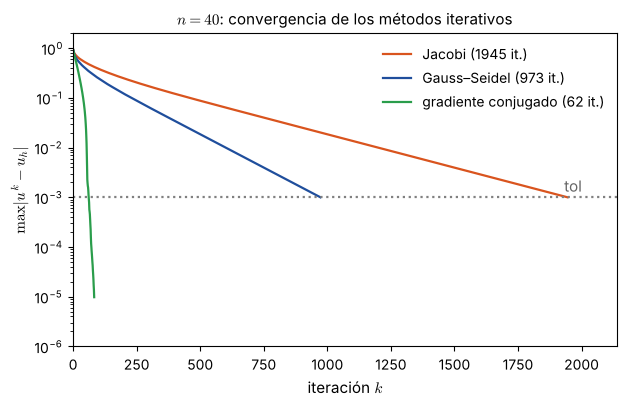

(c) pendiente de ln(error) contra k: Jacobi -0.00312 (ln cos(pi/n) = -0.00309), GS -0.00625; cociente 2.00


In [11]:
def jacobi(G, tol, u_ref, maxit=200000):
    """Jacobi desde u = 0 en el interior. Devuelve (k, u, hist)."""
    u = G.copy(); u[1:-1, 1:-1] = 0.0
    hist = [np.abs(u - u_ref).max()]
    while hist[-1] >= tol and len(hist) <= maxit:
        u[1:-1, 1:-1] = (u[2:, 1:-1] + u[:-2, 1:-1] + u[1:-1, 2:] + u[1:-1, :-2]) / 4
        hist.append(np.abs(u - u_ref).max())
    return len(hist) - 1, u, hist

def gauss_seidel_rn(G, tol, u_ref, maxit=200000):
    """Gauss-Seidel rojo-negro desde u = 0 en el interior. Devuelve (k, u, hist)."""
    n = G.shape[0] - 1
    u = G.copy(); u[1:-1, 1:-1] = 0.0
    rojo = (np.add.outer(np.arange(1, n), np.arange(1, n)) % 2 == 0)
    hist = [np.abs(u - u_ref).max()]
    while hist[-1] >= tol and len(hist) <= maxit:
        for color in (rojo, ~rojo):                       # primero los rojos, después los negros (ya con los rojos nuevos)
            prom = (u[2:, 1:-1] + u[:-2, 1:-1] + u[1:-1, 2:] + u[1:-1, :-2]) / 4
            u[1:-1, 1:-1] = np.where(color, prom, u[1:-1, 1:-1])
        hist.append(np.abs(u - u_ref).max())
    return len(hist) - 1, u, hist

# (b)
tol = 1e-3
iter_J, iter_GS, hist_J, hist_GS = {}, {}, {}, {}
for n in [20, 40, 80]:
    G = dato_borde(n)
    iter_J[n], _, hist_J[n] = jacobi(G, tol, soluciones[n])
    iter_GS[n], _, hist_GS[n] = gauss_seidel_rn(G, tol, soluciones[n])
exp_J = np.polyfit(np.log([20, 40, 80]), np.log([iter_J[n] for n in (20, 40, 80)]), 1)[0]
exp_GS = np.polyfit(np.log([20, 40, 80]), np.log([iter_GS[n] for n in (20, 40, 80)]), 1)[0]
print(f"(b) {'n':>4} {'Jacobi':>8} {'GS':>7} {'GS/J':>6} {'J(n)/J(n/2)':>12} {'predicción':>11}")
for n in [20, 40, 80]:
    pred = np.log(tol) / np.log(np.cos(np.pi / n))
    print(f"    {n:4d} {iter_J[n]:8d} {iter_GS[n]:7d} {iter_GS[n] / iter_J[n]:6.2f} {iter_J[n] / iter_J[n // 2] if n > 20 else float('nan'):12.2f} {pred:11.0f}")
print(f"    exponentes: Jacobi {exp_J:.2f}, Gauss-Seidel {exp_GS:.2f}")

# (d)
def iter_cg(n, tol):
    """Iteraciones de CG hasta que el error máximo contra la solución directa baje de tol (más la historia de errores)."""
    u_ref = soluciones[n] if n in soluciones else resolver(n, dato_borde(n))
    x_ref = u_ref[1:-1, 1:-1].ravel()
    hist = []
    spla.cg(ensamblar(n), rhs(n, dato_borde(n)), callback=lambda xk: hist.append(np.abs(xk - x_ref).max()), maxiter=5000)
    k = next(k + 1 for k, e in enumerate(hist) if e < tol)
    return k, hist

iter_CG, hist_CG = {}, {}
for n in [20, 40, 80, 160]:
    iter_CG[n], hist_CG[n] = iter_cg(n, tol)
exp_CG = np.polyfit(np.log([20, 40, 80, 160]), np.log([iter_CG[n] for n in (20, 40, 80, 160)]), 1)[0]
print(f"(d) iteraciones de CG (error < {tol:g}): " + ", ".join(f"n = {n}: {iter_CG[n]}" for n in iter_CG) + f"; exponente {exp_CG:.2f}")

# (c)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.semilogy(hist_J[40], color=COLORES["modelo"], label=f"Jacobi ({iter_J[40]} it.)")
ax.semilogy(hist_GS[40], color=COLORES["traj"], label=f"Gauss–Seidel ({iter_GS[40]} it.)")
ax.semilogy(np.arange(1, len(hist_CG[40]) + 1), hist_CG[40], color=CICLO[2], label=f"gradiente conjugado ({iter_CG[40]} it.)")
ax.axhline(tol, color="0.5", ls=":"); ax.text(ax.get_xlim()[1] * 0.98, tol * 1.3, "tol", ha="right", color="0.4")
ax.set_xlim(0, 1.1 * iter_J[40]); ax.set_ylim(1e-6, 2)
ax.set_xlabel("iteración $k$"); ax.set_ylabel(r"$\max|u^k - u_h|$"); ax.legend(); ax.set_title("$n = 40$: convergencia de los métodos iterativos")
fig.tight_layout(); plt.show()
pJ = np.polyfit(np.arange(300, 1200), np.log(hist_J[40][300:1200]), 1)[0]
pGS = np.polyfit(np.arange(150, 600), np.log(hist_GS[40][150:600]), 1)[0]
print(f"(c) pendiente de ln(error) contra k: Jacobi {pJ:.5f} (ln cos(pi/n) = {np.log(np.cos(np.pi / 40)):.5f}), GS {pGS:.5f}; cociente {pGS / pJ:.2f}")

In [12]:
# Verificación
assert 350 < iter_J[20] < 650 and 3.6 < iter_J[40] / iter_J[20] < 4.4 and 3.6 < iter_J[80] / iter_J[40] < 4.4, f"Jacobi: {iter_J}"
assert all(0.45 < iter_GS[n] / iter_J[n] < 0.56 for n in (20, 40, 80)), f"GS / Jacobi: {[iter_GS[n] / iter_J[n] for n in (20, 40, 80)]}, se esperaba ~1/2"
assert 1.85 < exp_J < 2.15 and 0.8 < exp_CG < 1.25, f"exponentes: Jacobi {exp_J:.2f}, CG {exp_CG:.2f}"
u_j = jacobi(dato_borde(20), 1e-8, soluciones[20])[1]
assert np.abs(u_j - soluciones[20]).max() < 1e-7, "Jacobi debería converger a la solución del sistema"
print("iterativos: OK")

iterativos: OK


**Para el docente.** Iteraciones para $\text{tol} = 10^{-3}$: Jacobi $485, 1945, 7786$ (cociente $4.01$ y $4.00$), Gauss–Seidel rojo–negro exactamente la mitad ($243, 973, 3894$); la predicción $\ln(\text{tol})/\ln\cos(\pi/n)$ da $558, 2237, 8956$ ($15\,\%$ más: el error inicial es menor que $1$). Pendiente de $\ln(\text{error})$: $-0.00312$ (Jacobi, contra $\ln\cos(\pi/40) = -0.00309$), $-0.00625$ (GS): cociente $2.00$. CG: $31, 62, 126, 252$ iteraciones (exponente $1.01$); el criterio de $\text{tol}$ contra la referencia es más exigente que el residuo relativo por defecto de `cg`, pero la corrida termina antes de que `cg` pare; si en otra versión de SciPy `cg` parara antes de llegar a $10^{-3}$, el `next(...)` da `StopIteration`: bajar la tolerancia con `rtol=1e-10` (`tol=` en versiones viejas). Errores típicos: escribir Jacobi con un bucle doble y actualizar `u` en el lugar (eso es Gauss–Seidel lexicográfico, converge en la mitad de iteraciones pero es lento en Python); en el rojo–negro, calcular `prom` una vez sola y asignar a las dos mitades (no es Gauss–Seidel); medir el error contra la solución exacta de Fourier en lugar de contra la del sistema (se estanca en el error de discretización, $10^{-3}$, y no baja de `tol`); contar `k` desfasado en uno. Tiempo: 25 minutos.

## 5. Con fuente: $-\Delta u = f$ y el juego con pago acumulado

Con una fuente, el esquema de cinco puntos es $-\Delta_h u = f$, es decir

$$u_{i,j} = \frac14\bigl(u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}\bigr) + \frac{h^2}{4}\,f_{i,j}.$$

**Cómo cambia el juego.** Ahora el jugador, además del pago final $g$ en el borde, **cobra $\frac{h^2}{4}f(p)$ cada vez que está parado en un nodo interior $p$** (contando el nodo de partida, y sin contar el del borde donde termina). Si $X_0 = p, X_1, \dots, X_T$ es el paseo ($X_T$ en el borde),

$$u(p) = \mathbb E\Bigl[\,g(X_T) + \frac{h^2}{4}\sum_{k=0}^{T-1} f(X_k)\Bigr].$$

*Por qué:* condicionando en el primer paso, $u(p) = \frac{h^2}{4}f(p) + \frac14\sum_{p'\sim p}u(p')$ (cobrás la fuente del nodo donde estás y seguís jugando desde el vecino al que fuiste), que es la ecuación de arriba. Es la versión discreta de la **fórmula de Feynman–Kac**: $u(x) = \mathbb E\bigl[g(B_\tau) + \int_0^\tau f(B_s)\,ds\bigr]$ para un movimiento browniano $B$ con generador $\Delta$, que sale del dominio en el instante aleatorio $\tau$. **El factor $h^2/4$** es lo que dura cada paso: para que el paseo con pasos de largo $h$ aproxime a un browniano con generador $\Delta$ (varianza $2t$ por coordenada, o sea $\mathbb E|X_t - X_0|^2 = 4t$ en el plano), cada paso tiene que durar $\tau_h = h^2/4$, y la integral $\int f\,ds$ se aproxima por $\sum f(X_k)\,\tau_h$.

Un caso particular que da la clave del costo. Con $g = 0$ y $f = 1$ resulta $u(p) = \frac{h^2}{4}\,\mathbb E[T]$: **la solución de $-\Delta u = 1$ con $u=0$ en el borde es (salvo el factor $h^2/4$) el número esperado de pasos hasta el borde**. En el centro del cuadrado unitario la solución de $-\Delta u = 1$ vale $\approx 0.0737$, de donde $\mathbb E[T] = 4u/h^2 \approx 0.295\,n^2$: es el "$0.29\,n^2$" que midieron en la Tarea 4.

**Principio del máximo con fuente.** Si $-\Delta u = f\ge0$ ($u$ superarmónica) el **mínimo** de $u$ está en el borde (y $u\ge\min g$), pero el **máximo puede estar adentro**: con $f=1$, $g=0$ la solución es positiva en todo el cuadrado y vale $0$ en el borde. Además vale el **principio de comparación**: si $f\ge0$, la solución con fuente es mayor o igual que la solución sin fuente (con el mismo $g$) en todo el cuadrado: sumás un pago extra no negativo al juego. Con $f\le0$ (subarmónica) es el máximo el que queda en el borde.

### Tarea 6: Con fuente: cinco puntos contra Monte Carlo con pago acumulado

**(a)** Escribí `valor_mc_f(i, j, M, G, F, rng=None)`: como `valor_mc` pero el jugador acumula $\frac{h^2}{4}F[i', j']$ en cada nodo interior $(i',j')$ en que está parado (incluyendo el de partida), con $h = 1/n$ y `F` un array $(n+1)\times(n+1)$ con los valores de $f$ en los nodos. Devuelve `(media, error_estandar, pasos)` con la media del pago total (final más acumulado).

**(b)** Caso $f = 1$, $g = 0$ ($n = 20$, `G = np.zeros((21, 21))`, `F = np.ones((21, 21))`). Compará Monte Carlo ($M = 20000$) con `resolver(20, G, F)` en los nodos $(10,10)$, $(5,5)$, $(10,3)$ y $(15,10)$: una tabla con el valor de cinco puntos, el de Monte Carlo, el error estándar y $z = (\text{MC} - \text{5p})/\text{error estándar}$. Con $n = 80$ y `resolver`, el valor en el centro aproxima el de la ecuación continua, $0.07367$: verificalo.

**(c)** *El tiempo de salida.* Con los mismos datos, `pasos / M` que devuelve `valor_mc_f` desde el centro es el número medio de pasos $\mathbb E[T]$. Verificá la relación $u_h(\text{centro}) = \frac{h^2}{4}\,\mathbb E[T]$ comparando $\frac{4}{h^2}\,u_h$ con `pasos / M`, y explicá por qué el $0.29\,n^2$ de la Tarea 4 sale de acá.

**(d)** Una fuente que no es constante ni un dato nulo: $f(x,y) = 40\,x$ y $g$ el dato de la Tarea 1 (`dato_borde(20)`). Repetí la comparación de (b) en los mismos nodos y verificá $|z| < 4$ en todos.

**(e)** *Principio del máximo.* Con `resolver` en $n = 40$ y $g=0$, calculá la solución para $f = +1$ y $f = -1$ y verificá: con $f = 1$ el mínimo interior es $\ge 0$ pero el máximo es $>0 = \max g$ (¿dónde está?); con $f=-1$ pasa lo simétrico. Con $g$ = `dato_borde(40)` y $f = 50\,\sin(\pi x)\sin(\pi y)\ge0$ verificá el principio de comparación: `u_con_fuente >= u_sin_fuente` en todos los nodos.

**Qué se espera.** (b) $z$ entre $-3$ y $3$ en los cuatro nodos (con $M = 20000$ el error estándar es del orden de $10^{-3}$, sobre valores de $0.04$ a $0.07$; como cada partida cobra sobre $\approx 100$ pasos, la desviación del pago total es del orden del propio valor); $u_h(0.5,0.5) = 0.0735$ en $n=20$ y $0.07366$ en $n=80$. (c) las dos cantidades coinciden dentro del error estadístico de la segunda ($\approx 1\%$); $\mathbb E[T]\approx 0.29\,n^2 = 118$ pasos en $n=20$. (e) máximo $\approx 0.0737$ en el centro con $f = 1$ y mínimo $\approx -0.0737$ en el centro con $f=-1$; la diferencia entre las dos soluciones con y sin fuente es no negativa en todos los nodos.

In [13]:
def valor_mc_f(i, j, M, G, F, rng=None):
    """Como valor_mc, pero acumulando h^2 F[i', j'] / 4 en cada nodo interior visitado (incluido el inicial).
    Devuelve (media, error_estandar, pasos_totales)."""
    rng = np.random.default_rng() if rng is None else rng
    n = G.shape[0] - 1; h = 1 / n
    ii, jj = np.full(M, i), np.full(M, j)
    pago = np.zeros(M)
    activo = np.ones(M, dtype=bool)
    pasos = 0
    while activo.any():
        k = np.flatnonzero(activo)
        pasos += k.size
        pago[k] += h ** 2 * F[ii[k], jj[k]] / 4                 # cobra la fuente del nodo donde está parado
        d = rng.integers(4, size=k.size)
        ii[k] += (d == 0).astype(int) - (d == 1)
        jj[k] += (d == 2).astype(int) - (d == 3)
        llego = (ii[k] == 0) | (ii[k] == n) | (jj[k] == 0) | (jj[k] == n)
        kf = k[llego]
        pago[kf] += G[ii[kf], jj[kf]]                            # pago final en el borde
        activo[kf] = False
    return pago.mean(), pago.std(ddof=1) / np.sqrt(M), pasos

n = 20; h = 1 / n
G0 = np.zeros((n + 1, n + 1)); F1 = np.ones((n + 1, n + 1))
nodos = [(10, 10), (5, 5), (10, 3), (15, 10)]

def comparar(G, F, M, semilla, etiqueta):
    u5 = resolver(n, G, F)
    print(f"{etiqueta}\n    {'nodo':>8} {'cinco puntos':>13} {'Monte Carlo':>12} {'error est.':>11} {'z':>6}")
    zs = []
    for k, (i, j) in enumerate(nodos):
        media, ee, pasos = valor_mc_f(i, j, M, G, F, np.random.default_rng(semilla + k))
        zs.append((media - u5[i, j]) / ee)
        print(f"    {str((i, j)):>8} {u5[i, j]:13.5f} {media:12.5f} {ee:11.5f} {zs[-1]:6.2f}")
    return u5, zs

# (b)
u5_b, z_b = comparar(G0, F1, 20000, 1, "(b) f = 1, g = 0, M = 20000")
u80 = resolver(80, np.zeros((81, 81)), 1.0)
print(f"    n = 80: u(centro) = {u80[40, 40]:.5f} (ecuación continua: 0.07367); n = 20: {u5_b[10, 10]:.5f}")

# (c)
media, ee, pasos = valor_mc_f(10, 10, 20000, G0, F1, np.random.default_rng(7))
print(f"(c) 4 u_h / h^2 = {4 * u5_b[10, 10] / h ** 2:.1f};  pasos medios desde el centro = {pasos / 20000:.1f};  c = {u5_b[10, 10] * 4 / h ** 2 / n ** 2:.4f} (Tarea 4: c_T = {c_T:.3f})")

# (d)
x = np.linspace(0, 1, n + 1); X, Y = np.meshgrid(x, x)
u5_d, z_d = comparar(dato_borde(n), 40 * X, 20000, 100, "(d) f = 40 x, g de la Tarea 1")

# (e)
n2 = 40; G2 = np.zeros((n2 + 1, n2 + 1))
for f_c in (1.0, -1.0):
    u = resolver(n2, G2, f_c); ui = u[1:-1, 1:-1]
    k = np.unravel_index(np.abs(ui).argmax(), ui.shape)
    print(f"(e) f = {f_c:+.0f}, g = 0: min interior {ui.min():+.4f}, max interior {ui.max():+.4f}; extremo en el nodo {(int(k[0] + 1), int(k[1] + 1))} (el centro es {(n2 // 2, n2 // 2)})")
x2 = np.linspace(0, 1, n2 + 1); X2, Y2 = np.meshgrid(x2, x2)
Gd = dato_borde(n2)
u_sin = resolver(n2, Gd); u_con = resolver(n2, Gd, 50 * np.sin(np.pi * X2) * np.sin(np.pi * Y2))
print(f"    comparación: min(u_con - u_sin) = {(u_con - u_sin).min():.2e} >= 0; el máximo de u_con ({u_con[1:-1, 1:-1].max():.3f}) vs max g = 1: "
      f"{'supera' if u_con[1:-1, 1:-1].max() > 1 else 'no supera'} el máximo del borde")

(b) f = 1, g = 0, M = 20000
        nodo  cinco puntos  Monte Carlo  error est.      z


    (10, 10)       0.07353      0.07302     0.00036  -1.40


      (5, 5)       0.04518      0.04527     0.00033   0.27
     (10, 3)       0.04025      0.04016     0.00033  -0.27


    (15, 10)       0.05722      0.05686     0.00036  -1.01
    n = 80: u(centro) = 0.07366 (ecuación continua: 0.07367); n = 20: 0.07353
(c) 4 u_h / h^2 = 117.6;  pasos medios desde el centro = 119.0;  c = 0.2941 (Tarea 4: c_T = 0.294)
(d) f = 40 x, g de la Tarea 1
        nodo  cinco puntos  Monte Carlo  error est.      z


    (10, 10)       1.72053      1.71915     0.00841  -0.16
      (5, 5)       0.72994      0.72463     0.00720  -0.74
     (10, 3)       0.65010      0.65457     0.00707   0.63


    (15, 10)       1.68420      1.67903     0.00713  -0.73
(e) f = +1, g = 0: min interior +0.0014, max interior +0.0736; extremo en el nodo (20, 20) (el centro es (20, 20))
(e) f = -1, g = 0: min interior -0.0736, max interior -0.0014; extremo en el nodo (20, 20) (el centro es (20, 20))
    comparación: min(u_con - u_sin) = 0.00e+00 >= 0; el máximo de u_con (2.798) vs max g = 1: supera el máximo del borde


In [14]:
# Verificación
assert all(abs(z) < 4 for z in z_b), f"(b) z = {z_b}"
assert all(abs(z) < 4 for z in z_d), f"(d) z = {z_d}"
assert abs(u80[40, 40] - 0.07367) < 2e-4, "el valor en el centro para n = 80 debería ser ~0.07367"
m_, e_, p_ = valor_mc_f(10, 10, 20000, G0, F1, np.random.default_rng(3))
assert abs(4 * m_ / (1 / 20) ** 2 - p_ / 20000) < 0.05 * p_ / 20000, "u = (h^2/4) E[T] con f = 1, g = 0"
assert resolver(40, np.zeros((41, 41)), 1.0)[1:-1, 1:-1].min() > 0
print("con fuente: OK")

con fuente: OK


**Para el docente.** (b) Con $M = 20000$, en los nodos $(10,10), (5,5), (10,3), (15,10)$: cinco puntos $0.07353, 0.04518, 0.04025, 0.05722$; Monte Carlo $0.07302, 0.04527, 0.04016, 0.05686$, con errores estándar $\approx3.5\times10^{-4}$ ($z = -1.4, 0.3, -0.3, -1.0$). En $n = 80$: $0.07366$ (la ecuación continua: $0.073671$, de la serie; el error de $n=20$ es $1.4\times10^{-4}$, $O(h^2)$). (c) $4u_h/h^2 = 117.6$ contra $119.0\pm1.2$ pasos medios: $c = 0.2941$; el mismo $c$ de la Tarea 4. (d) $f = 40x$: valores $1.72, 0.73, 0.65, 1.68$ con errores estándar $\approx0.008$ y $|z|<0.8$. (e) $f=1$: mínimo interior $+0.0014$ (nodo pegado al borde) y máximo $+0.0736$ en el centro; $f=-1$: simétrico; con $f = 50\sin\pi x\sin\pi y$, $u_{\text{con}} - u_{\text{sin}}\ge 0$ (mínimo exacto $0$: en los nodos del borde ambas coinciden), y el máximo de $u_{con}$ es $2.80 > 1 = \max g$. Errores típicos: cobrar $h^2 f/4$ *después* de moverse (se pierde el nodo inicial o se cobra el nodo del borde: diferencia de un término de orden $h^2$, invisible con $M$ chico: hay que mirar que $z$ es sistemáticamente de un signo con $M = 10^5$); olvidar el $/4$ (da valores $4$ veces mayores); usar $h^2 f$ con $h=1$; dividir por $M$ en lugar de tomar la media de la suma. Tiempo: 25 minutos.

## 6. Inpainting: rellenar una región resolviendo Laplace

### La idea

Una imagen en escala de grises es una función $I(p)$ sobre los píxeles $p$ de una grilla. Si una región $\Omega$ de la imagen se pierde (un rayón, un objeto que queremos sacar), ¿con qué la rellenamos? Una respuesta natural es: **con la función más suave que empalme con lo que rodea a la región**. "Más suave" se puede precisar como la de menor energía de gradiente,

$$\min_u \int_\Omega |\nabla u|^2\,dx\qquad\text{con } u = I \text{ en } \partial\Omega,$$

y ya sabemos (Capítulo 19) que el minimizador es la solución del problema de Dirichlet $\Delta u = 0$ en $\Omega$, $u = I$ en $\partial\Omega$: la función armónica con esos datos de borde. Discretamente, el "borde" de la región es el anillo de píxeles que la rodean, con sus valores conocidos, y cada píxel $p\in\Omega$ satisface la ecuación de promedios: $u_p$ es el promedio de sus cuatro vecinos. Es exactamente el esquema de cinco puntos, con $h = 1$ (el paso de la grilla de píxeles; no interviene, porque $f = 0$) y con un dominio de **forma arbitraria**.

### El sistema lineal sobre los píxeles de la región

Las incógnitas son sólo los $N = |\Omega|$ píxeles de la región. Numerémoslos (por ejemplo con `np.argwhere(mascara)`, que los lista por filas, y un array `idx` del tamaño de la imagen con el número de cada píxel de $\Omega$ y $-1$ afuera). Para cada píxel $p\in\Omega$ con vecinos $q\sim p$ (arriba, abajo, izquierda, derecha):

$$4\,u_p - \sum_{q\sim p,\ q\in\Omega} u_q = \sum_{q\sim p,\ q\notin\Omega} I_q .$$

Los vecinos que están dentro de la región son incógnitas (van a la matriz, con coeficiente $-1$); los que están afuera son dato (van al lado derecho). La matriz $A$ ($N\times N$) tiene $4$ en la diagonal y $-1$ en las posiciones de los vecinos internos: rala (a lo sumo $5$ por fila), simétrica y definida positiva, igual que la de la Tarea 1 pero sin la estructura de Kronecker (la región es arbitraria). Se arma con **tres listas** (filas, columnas, valores) vectorizadas por direcciones, sin bucles sobre píxeles: para cada dirección $(d_i, d_j)$ se calcula el vecino de todos los píxeles a la vez, se ve cuáles caen dentro de $\Omega$ (`idx[vecino] >= 0`), y esos aportan entradas a la matriz y los otros aportan `I[vecino]` al lado derecho. Con `sp.csr_matrix((valores, (filas, columnas)))` y `spla.spsolve` se resuelve. (La región no puede tocar el borde de la imagen: para simplificar, se pide que la máscara esté al menos a un píxel de distancia.) **Costo:** una región de $100\times100$ píxeles son $10^4$ incógnitas, milisegundos; borrar la imagen entera ($262144$ incógnitas) es un sistema ralo de tamaño $N = 512^2$, de unos segundos: la Tarea 2 con una forma distinta.

Una **prueba de escritorio** muy útil: una función *discretamente armónica* (como $I_{i,j} = i^2 - j^2$ o $I_{i,j} = ij$: comprobá que el promedio de los cuatro vecinos es igual al valor central) tiene que ser recuperada **exactamente** al borrar cualquier región y rellenarla. Si no lo es, hay un error en el armado del sistema.

### Por qué funciona en un fondo liso, y por qué no en una textura

Sea $J$ la imagen rellenada y $e = J - I$ el error dentro de $\Omega$. Como $\Delta_h J = 0$ en $\Omega$, resulta $-\Delta_h e = \Delta_h I$ en $\Omega$ con $e = 0$ en el borde: **el error es la solución de un problema de Poisson cuya fuente es el Laplaciano de la imagen original** (Tarea 6). Si el fondo es liso, $\Delta_h I\approx0$ y $e\approx0$; el error crece con la región (una región de lado $L$ tiene un error que crece como $L^2\max|\Delta_hI|$, que es de lo que viene el $0.0737\,L^2$ de $-\Delta u = 1$) y con el tamaño del Laplaciano de $I$, que en una textura (pelo, pliegues de una tela) es grande: la imagen oscila a la escala del píxel.

Y hay una razón más profunda, que es el **principio del máximo**: una función armónica no tiene máximos ni mínimos locales adentro, así que **todo lo que se rellena está entre el mínimo y el máximo del anillo**, y no puede crear ningún detalle (una mancha más clara que su entorno, una línea, un borde nuevo): sólo interpola suavemente. Lo que sale de una textura es un manchón **más suave que el entorno** (con menos desvío estándar que la imagen original), sin la variación que tenía. Y no hay parámetro que lo arregle: es una propiedad de la ecuación. (Los bordes que atraviesan la región se difuminan por lo mismo.)

**Medidas.** Para cada región conviene reportar (i) el error cuadrático medio de $J - I$ dentro de $\Omega$; (ii) el desvío estándar de $I$ y el de $J$ dentro de $\Omega$ (¿cuánto detalle se perdió?); (iii) la comparación con el relleno más tonto, la constante igual al promedio del anillo; y (iv) el chequeo del principio del máximo. Ojo: el **error cuadrático medio no es la calidad visual**: rellenar con la función suave suele tener menor error que rellenar con una textura *plausible pero distinta*, aunque la segunda "se vea mejor" (Tarea 8).

**Lectura: los métodos reales usan más.** El inpainting de la literatura reemplaza $\Delta u = 0$ por ecuaciones que propagan también las direcciones de los bordes hacia adentro de la región (Bertalmío, Sapiro, Caselles y Ballester, *Image inpainting*, SIGGRAPH 2000) o que copian texturas de otras partes de la imagen; y el *Poisson image editing* (Pérez, Gangnet y Blake, SIGGRAPH 2003) resuelve $\Delta u = \operatorname{div}\mathbf v$ con $u = I$ en el borde y un campo guía $\mathbf v$ (por ejemplo el gradiente de otra imagen), que es la Tarea 8. Todos terminan en un sistema lineal ralo como el de arriba.

In [15]:
# La imagen y unas herramientas (esta celda viene dada)
# datos/astronauta.png: Eileen Collins (NASA), 512 x 512 en escala de grises, dominio público (datos/README.md)
I = np.asarray(plt.imread(datos.obtener("astronauta.png")), dtype=float)
if I.max() > 1.5:
    I = I / 255.0
print("imagen:", I.shape, f"valores en [{I.min():.2f}, {I.max():.2f}]")

def rect(r0, r1, c0, c1):
    """Máscara booleana del rectángulo de filas r0..r1-1 y columnas c0..c1-1."""
    m = np.zeros(I.shape, dtype=bool); m[r0:r1, c0:c1] = True
    return m

def cuadrado(centro, L):
    """Máscara del cuadrado de lado L centrado en el píxel (fila, columna) `centro`."""
    r, c = centro
    return rect(r - L // 2, r - L // 2 + L, c - L // 2, c - L // 2 + L)

def anillo(mascara):
    """Píxeles que rodean a la región (vecinos de la región que no están en ella)."""
    from scipy.ndimage import binary_dilation
    return binary_dilation(mascara) & ~mascara

imagen: (512, 512) valores en [0.00, 1.00]


### Tarea 7: Inpainting: fondo liso contra textura

**(a)** Escribí `rellenar(I, mascara)`: devuelve una copia de `I` en la que los píxeles de `mascara` se reemplazaron por la solución de $\Delta_h u = 0$ con el anillo de la región como dato (sistema ralo sobre los píxeles de la región, como en el texto de arriba; sin bucles sobre píxeles). Probala con una imagen de prueba armónica: `I_prueba[i, j] = (i**2 - j**2)/1e4 + i*j/1e4 + 0.3` de $100\times100$ con un cuadrado borrado: se tiene que recuperar exacto.

**(b)** Dos casos. **Región chica sobre fondo liso:** `mascara_liso = rect(40, 70, 315, 345)` (la pared entre la cabeza y el transbordador, arriba a la derecha; $30\times30$ píxeles). **Región grande sobre textura:** `mascara_pelo = rect(25, 95, 180, 260)` (el pelo; $70\times80$ píxeles). Para cada una calculá el relleno y armá una figura de $2\times4$ paneles (una fila por caso): la imagen original con la región marcada, la imagen con la región borrada (poné los píxeles borrados en `np.nan`, o en `1.0` si preferís, y aclará cuál), la imagen rellenada y el mapa del error $|J - I|$ dentro de la región (ojo con la escala de color del error: usá la misma para los dos casos). Mostrá un zoom de la zona (por ejemplo `I[r0-20:r1+20, c0-20:c1+20]`), no la imagen entera de $512\times 512$, así se ve el resultado.

**(c)** Para cada caso imprimí: el error cuadrático medio $\text{ECM}$ de $J - I$ en la región, el desvío estándar de $I$ y de $J$ en la región, el porcentaje de detalle perdido $1 - \operatorname{sd}(J)/\operatorname{sd}(I)$, el ECM del relleno constante (promedio del anillo) y el chequeo del principio del máximo (`J[mascara]` entre el mínimo y el máximo de `I[anillo(mascara)]`). Guardalos en el diccionario `medidas["liso"]` y `medidas["pelo"]` con las claves `"ecm"`, `"sd_I"`, `"sd_J"`, `"ecm_const"`, `"en_rango"`.

**(d)** *Tamaño de la región.* Para cuadrados de lado $L = 6, 12, 24, 48$ centrados en la pared $(80, 330)$ y en el pelo $(60, 220)$ calculá el ECM y graficalo contra $L$ (log-log, dos curvas). ¿Cómo depende del tamaño en cada caso? Guardalo en `ecm_L["pared"]` y `ecm_L["pelo"]` (listas en el orden de $L$).

**Qué se espera.** (b) En la pared el relleno es indistinguible del original a simple vista; en el pelo se ve un manchón suave, sin mechones, empalmado con el contorno. (c) Pared: $\text{ECM}\approx0.016$, $\text{sd}(I)\approx0.02$; pelo: $\text{ECM}\approx0.14$, $\text{sd}(I)\approx0.18$ y $\text{sd}(J)\approx0.09$ (se pierde la mitad del detalle); el ECM del pelo es $\approx 9$ veces el de la pared; el relleno suave le gana al constante, y en los dos casos el relleno cae dentro del rango del anillo (**es** el principio del máximo, no un accidente). (d) En la pared el error crece con $L$ pero se mantiene chico ($\approx0.005$ con $L=6$ y $\approx0.02$ con $L=48$); en el pelo ya es grande con $L = 6$ ($\approx0.06$: una región de $6\times6$ dentro de una textura no se puede adivinar) y llega a $\approx0.15$ con $L=48$, que es más o menos el desvío de la textura: a partir de cierto tamaño rellenar con Laplace no mejora al relleno constante.

(a) imagen armónica: error máximo de la recuperación = 3.2e-15


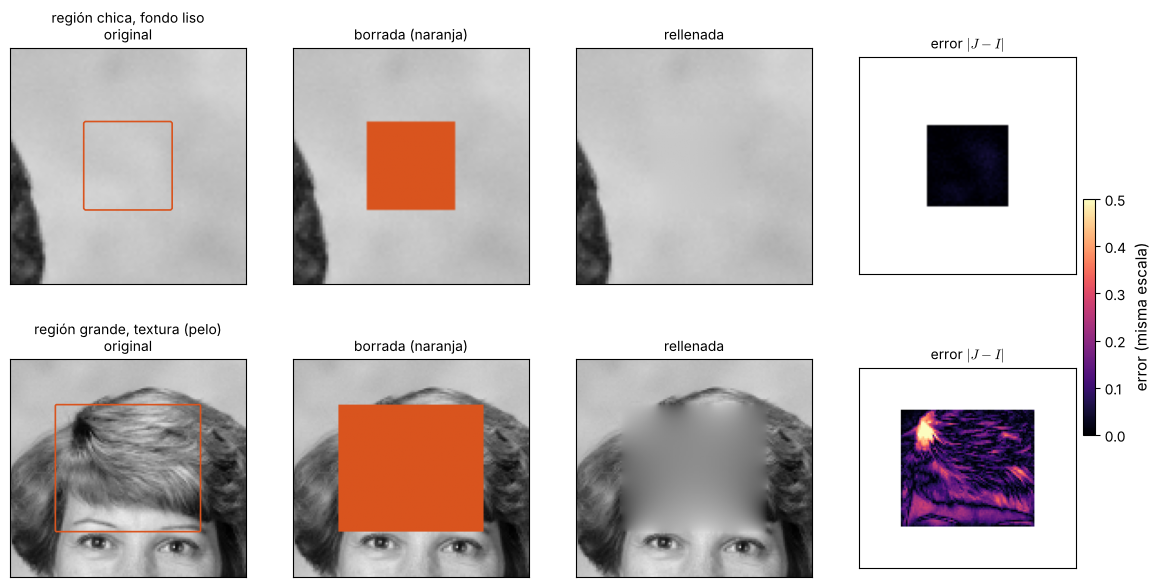

(c)   caso     ECM   sd(I)   sd(J)  detalle perdido  ECM constante  en el rango del anillo
      liso  0.0166  0.0167  0.0140              17%         0.0190                    True
      pelo  0.1437  0.1746  0.0936              46%         0.1748                    True


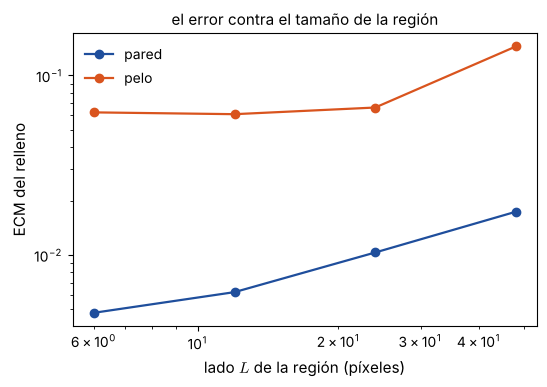

(d) ECM por lado L = [6, 12, 24, 48]
     pared: 0.0048, 0.0062, 0.0103, 0.0174
      pelo: 0.0623, 0.0609, 0.0663, 0.1451


In [16]:
def rellenar(I, mascara):
    """Copia de I con los píxeles de `mascara` rellenados resolviendo Laplace discreto con el anillo como dato."""
    P = np.argwhere(mascara)                       # coordenadas (fila, columna) de los N píxeles de la región
    N = len(P)
    idx = -np.ones(I.shape, dtype=int)
    idx[mascara] = np.arange(N)                    # número de cada píxel de la región (-1 afuera)
    filas, cols, vals = [np.arange(N)], [np.arange(N)], [np.full(N, 4.0)]
    b = np.zeros(N)
    for di, dj in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        Q = P + np.array([di, dj])                 # el vecino en esa dirección de cada píxel de la región
        q = idx[Q[:, 0], Q[:, 1]]
        dentro = q >= 0
        filas.append(np.flatnonzero(dentro)); cols.append(q[dentro]); vals.append(-np.ones(dentro.sum()))
        b[~dentro] += I[Q[~dentro, 0], Q[~dentro, 1]]        # vecinos conocidos: al lado derecho
    A = sp.csr_matrix((np.concatenate(vals), (np.concatenate(filas), np.concatenate(cols))), shape=(N, N))
    J = I.copy()
    J[mascara] = spla.spsolve(A.tocsc(), b)
    return J

def ecm(J, I, mascara):
    return np.sqrt(np.mean((J - I)[mascara] ** 2))

# (a)
ii, jj = np.meshgrid(np.arange(100), np.arange(100), indexing="ij")
I_prueba = (ii ** 2 - jj ** 2) / 1e4 + ii * jj / 1e4 + 0.3
m_prueba = np.zeros((100, 100), dtype=bool); m_prueba[30:60, 40:70] = True
print(f"(a) imagen armónica: error máximo de la recuperación = {np.abs(rellenar(I_prueba, m_prueba) - I_prueba).max():.1e}")

# (b)
mascara_liso = rect(40, 70, 315, 345)
mascara_pelo = rect(25, 95, 180, 260)
casos = {"liso": mascara_liso, "pelo": mascara_pelo}
J = {k: rellenar(I, m) for k, m in casos.items()}

fig, axs = plt.subplots(2, 4, figsize=(14, 7.2))
titulos = {"liso": "región chica, fondo liso", "pelo": "región grande, textura (pelo)"}
vmax_err = 0.5
for fila, (k, m) in enumerate(casos.items()):
    r, c = np.nonzero(m)
    sl = (slice(max(r.min() - 25, 0), r.max() + 26), slice(max(c.min() - 25, 0), c.max() + 26))
    borrada = np.where(m, np.nan, I)
    cmap_g = plt.get_cmap("gray").copy(); cmap_g.set_bad("#d9541e")
    paneles = [(I, "original"), (borrada, "borrada (naranja)"), (J[k], "rellenada"), (np.where(m, np.abs(J[k] - I), np.nan), r"error $|J - I|$")]
    for col, (im_, tit) in enumerate(paneles):
        ax = axs[fila, col]
        if col < 3:
            ax.imshow(im_[sl], cmap=cmap_g, vmin=0, vmax=1)
            if col == 0:
                ax.contour(m[sl], levels=[0.5], colors="#d9541e", linewidths=1.2)
        else:
            h_ = ax.imshow(im_[sl], cmap="magma", vmin=0, vmax=vmax_err)
        ax.set_title(f"{titulos[k]}\n{tit}" if col == 0 else tit, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(h_, ax=axs[:, 3], fraction=0.05, pad=0.03, shrink=0.8, label="error (misma escala)")
plt.show()

# (c)
medidas = {}
print(f"(c) {'caso':>6} {'ECM':>7} {'sd(I)':>7} {'sd(J)':>7} {'detalle perdido':>16} {'ECM constante':>14} {'en el rango del anillo':>23}")
for k, m in casos.items():
    a = I[anillo(m)]
    medidas[k] = dict(ecm=ecm(J[k], I, m), sd_I=I[m].std(), sd_J=J[k][m].std(),
                      ecm_const=np.sqrt(np.mean((I[m] - a.mean()) ** 2)),
                      en_rango=bool(J[k][m].min() >= a.min() - 1e-9 and J[k][m].max() <= a.max() + 1e-9))
    d = medidas[k]
    print(f"    {k:>6} {d['ecm']:7.4f} {d['sd_I']:7.4f} {d['sd_J']:7.4f} {100 * (1 - d['sd_J'] / d['sd_I']):15.0f}% {d['ecm_const']:14.4f} {str(d['en_rango']):>23}")

# (d)
Ls = [6, 12, 24, 48]
centros = {"pared": (80, 330), "pelo": (60, 220)}
ecm_L = {k: [ecm(rellenar(I, cuadrado(c, L)), I, cuadrado(c, L)) for L in Ls] for k, c in centros.items()}
fig, ax = plt.subplots(figsize=(5.6, 4))
for k, col in zip(ecm_L, [COLORES["traj"], COLORES["modelo"]]):
    ax.loglog(Ls, ecm_L[k], "o-", color=col, label=k)
ax.set_xlabel("lado $L$ de la región (píxeles)"); ax.set_ylabel("ECM del relleno"); ax.legend(); ax.set_title("el error contra el tamaño de la región")
fig.tight_layout(); plt.show()
print("(d) ECM por lado L =", Ls)
for k in ecm_L:
    print(f"    {k:>6}: " + ", ".join(f"{e:.4f}" for e in ecm_L[k]))

In [17]:
# Verificación
mp = np.zeros((100, 100), dtype=bool); mp[30:60, 40:70] = True
assert np.abs(rellenar(I_prueba, mp) - I_prueba).max() < 1e-9, "la imagen armónica de prueba no se recupera exacta"
assert np.abs(rellenar(I, mascara_liso)[~mascara_liso] - I[~mascara_liso]).max() == 0, "fuera de la región no se toca nada"
m1, m2 = medidas["liso"], medidas["pelo"]
assert m1["ecm"] < 0.03 and m2["ecm"] > 3 * m1["ecm"], f"ECM liso {m1['ecm']:.3f}, pelo {m2['ecm']:.3f}: el del pelo debería ser mucho mayor"
assert m2["sd_J"] < 0.75 * m2["sd_I"], "en la textura el relleno debería ser más suave que el original"
assert m1["en_rango"] and m2["en_rango"], "el relleno debe caer dentro del rango del anillo (principio del máximo)"
assert all(a < b for a, b in zip(ecm_L["pared"], ecm_L["pelo"])), "para cada L el error en el pelo debería ser mayor"
print("inpainting: OK")

inpainting: OK


**Para el docente.** Imagen: $512\times512$, valores en $[0,1]$. Prueba armónica: error de recuperación $3\times10^{-15}$. Pared ($30\times30$, `rect(40, 70, 315, 345)`): $\text{ECM} = 0.0166$, $\text{sd}(I) = 0.0167$, $\text{sd}(J) = 0.0140$, constante $0.0190$: el error es esencialmente el **grano** de la foto (que ninguna función armónica reproduce), no la variación suave; el relleno le gana muy poco al constante porque la pared es casi constante. Pelo ($70\times80$): $\text{ECM} = 0.1437$, $\text{sd}(I) = 0.1746$, $\text{sd}(J) = 0.0936$ ($46\,\%$ de detalle perdido), constante $0.1748$; los dos caen dentro del rango del anillo. Ratio de ECM pelo/pared $= 8.7$. Por lado $L = 6, 12, 24, 48$: pared $0.0048, 0.0062, 0.0103, 0.0174$; pelo $0.0623, 0.0609, 0.0663, 0.1451$ (el pelo en $L=6$ ya vale más de $10$ veces la pared: aun en un agujero minúsculo la textura no se interpola; la curva es casi plana hasta $L=24$ y luego sube a $\text{sd}(I)$: a partir de ahí Laplace no mejora al constante). Ojo con la figura: los píxeles borrados están en naranja, y el mapa del error usa la misma escala para los dos casos (con escalas distintas la pared parecería tan mala como el pelo). Errores típicos: armar la matriz con bucles sobre píxeles (funciona con $N = 6000$ pero tarda decenas de segundos con $N = 5\times10^4$); confundir filas y columnas en `rect` o en el zoom; no restar el signo (poner $+I_q$ en la matriz en lugar de en el lado derecho) —el resultado sale con brillo invertido—; incluir en el anillo píxeles de la región; olvidar que `plt.imread` da `float32` (no afecta) o que da $[0,255]$ (la celda dada ya lo normaliza). Tiempo: 45–50 minutos, es la tarea más larga.

### (Opcional) Rellenar con una fuente: Poisson guiado y clonado de textura

La solución de Laplace es la más suave posible: no puede crear detalle. Para conseguir **detalle** hay que dárselo, y la ecuación de Poisson es el modo natural: si en lugar de $\Delta u = 0$ resolvemos

$$\Delta u = \Delta S\ \text{ en }\Omega,\qquad u = I\ \text{ en }\partial\Omega,$$

donde $S$ es **otra imagen** (o la misma imagen desplazada), $u$ tiene, dentro de $\Omega$, el mismo Laplaciano —el mismo "detalle"— que $S$, y empalma con $I$ en el borde: es la solución de $\min\int_\Omega|\nabla u - \nabla S|^2$ con $u=I$ en $\partial\Omega$, es decir, la imagen que **más se parece en gradientes a $S$ y coincide con $I$ en el borde**. La costura desaparece porque el dato de borde es el de $I$: las diferencias de brillo entre $S$ e $I$ se reparten suavemente por la región. Esto es el *Poisson image editing*. En el lenguaje de la Sección 5, es $-\Delta u = f$ con $f = -\Delta_h S$. Discretamente, la ecuación del píxel $p\in\Omega$ es

$$4u_p - \sum_{q\sim p,\ q\in\Omega}u_q = \sum_{q\sim p,\ q\notin\Omega}I_q - (\Delta_h S)_p,\qquad (\Delta_h S)_p = \sum_{q\sim p}S_q - 4S_p ,$$

el mismo sistema que en la Tarea 7 con un término más en el lado derecho. **Dos pruebas de escritorio:** si $S = I$ (la guía es la propia imagen), $\Delta_hu = \Delta_hI$ con el mismo borde: $u = I$, se recupera la imagen exacta; y si $S$ es constante, $\Delta_hS=0$ y volvemos a Laplace. Como $f\ne0$, **el principio del máximo ya no vale**: el relleno puede salirse del rango del anillo (y es lo que hace falta para agregar detalle).

### Tarea 8: (Opcional) Poisson guiado: clonar textura

**(a)** Escribí `rellenar_guiado(I, mascara, guia)`: como `rellenar`, pero con la guía `guia` (un array del tamaño de la imagen) y el lado derecho corregido con $-(\Delta_h S)_p$. Verificá las dos pruebas de escritorio: con `guia = I` se recupera `I` exacta, y con `guia = np.full(I.shape, 0.5)` da lo mismo que `rellenar`.

**(b)** Rellená el pelo (`mascara_pelo` de la Tarea 7) con la guía `S = np.roll(I, (0, -30), axis=(0, 1))` (o sea `S[r, c] = I[r, c + 30]`: el pelo 30 píxeles a la derecha, es decir, la propia textura del pelo desplazada). Mostrá en una figura (con zoom) el original, el relleno de Laplace (Tarea 7), el relleno guiado y el mapa de $|J-I|$ del guiado, y calculá: el ECM del guiado, el desvío estándar del relleno guiado dentro de la región y el chequeo del principio del máximo. Guardalos en `medidas_g` con las claves `"ecm"`, `"sd_J"` y `"en_rango"`.

**(c)** Probá otra guía a tu elección (otro desplazamiento, la imagen espejada, otra parte del cuerpo...) y anotá qué pasa cuando la textura de la guía no se parece a la del entorno.

**Qué se espera.** (a) errores $\lesssim10^{-9}$. (b) el relleno guiado **se ve mucho mejor**: tiene mechones y contraste, y empalma con el contorno sin costura; pero su ECM contra el original es **mayor** que el de Laplace ($\approx0.21$ contra $\approx0.14$): la textura plausible pero *desalineada* con la real ($30$ píxeles corridos) tiene un error de amplitud comparable a la de la propia textura, y el suave, que es el "promedio" de todas las posibilidades, minimiza el error cuadrático. El desvío estándar del relleno guiado ($\approx 0.15$) es mucho más parecido al del original ($\approx0.17$) que el de Laplace ($\approx0.09$), y el chequeo del principio del máximo **falla** (el relleno se sale del rango del anillo, porque $f\neq0$). Ojo con esa lección: el ECM mide *cuánto se parece al original*, no *cuán creíble es el resultado*.

(a) guia = I: error máximo 1.1e-14; guia constante contra rellenar: 0.0e+00
(b) Laplace: ECM 0.1437, sd 0.0936, en rango: True
    guiado : ECM 0.2088, sd 0.1521, en rango: False (rango del relleno [0.08, 0.90], rango del anillo [0.08, 0.86]); sd del original: 0.1746


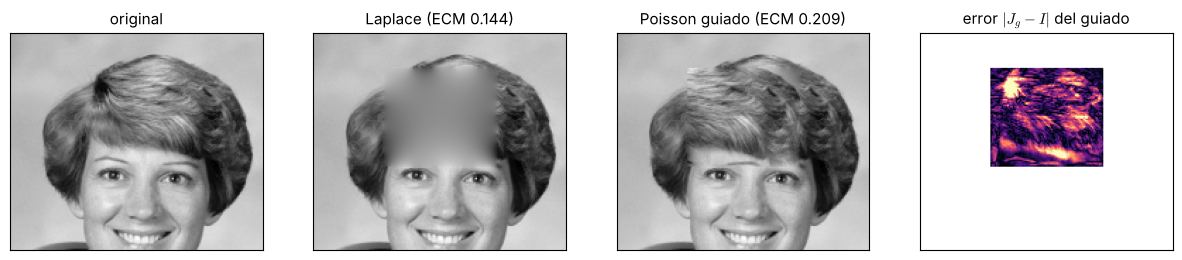

In [18]:
def rellenar_guiado(I, mascara, guia):
    """Como rellenar, pero con Delta u = Delta guia en la región (Poisson guiado)."""
    P = np.argwhere(mascara)
    N = len(P)
    idx = -np.ones(I.shape, dtype=int)
    idx[mascara] = np.arange(N)
    filas, cols, vals = [np.arange(N)], [np.arange(N)], [np.full(N, 4.0)]
    b = -(-4.0 * guia[P[:, 0], P[:, 1]])                     # -(Delta_h guia)_p = 4 S_p - sum(S de los vecinos)
    for di, dj in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        Q = P + np.array([di, dj])
        q = idx[Q[:, 0], Q[:, 1]]
        dentro = q >= 0
        filas.append(np.flatnonzero(dentro)); cols.append(q[dentro]); vals.append(-np.ones(dentro.sum()))
        b[~dentro] += I[Q[~dentro, 0], Q[~dentro, 1]]
        b -= guia[Q[:, 0], Q[:, 1]]
    A = sp.csr_matrix((np.concatenate(vals), (np.concatenate(filas), np.concatenate(cols))), shape=(N, N))
    Jg = I.copy()
    Jg[mascara] = spla.spsolve(A.tocsc(), b)
    return Jg

# (a)
print(f"(a) guia = I: error máximo {np.abs(rellenar_guiado(I, mascara_pelo, I) - I).max():.1e}; "
      f"guia constante contra rellenar: {np.abs(rellenar_guiado(I, mascara_pelo, np.full(I.shape, 0.5)) - J['pelo']).max():.1e}")

# (b)
guia = np.roll(I, (0, -30), axis=(0, 1))
Jg = rellenar_guiado(I, mascara_pelo, guia)
a = I[anillo(mascara_pelo)]
medidas_g = dict(ecm=ecm(Jg, I, mascara_pelo), sd_J=Jg[mascara_pelo].std(),
                 en_rango=bool(Jg[mascara_pelo].min() >= a.min() - 1e-9 and Jg[mascara_pelo].max() <= a.max() + 1e-9))
print(f"(b) Laplace: ECM {medidas['pelo']['ecm']:.4f}, sd {medidas['pelo']['sd_J']:.4f}, en rango: {medidas['pelo']['en_rango']}")
print(f"    guiado : ECM {medidas_g['ecm']:.4f}, sd {medidas_g['sd_J']:.4f}, en rango: {medidas_g['en_rango']} "
      f"(rango del relleno [{Jg[mascara_pelo].min():.2f}, {Jg[mascara_pelo].max():.2f}], rango del anillo [{a.min():.2f}, {a.max():.2f}]); sd del original: {medidas['pelo']['sd_I']:.4f}")

r, c = np.nonzero(mascara_pelo)
sl = (slice(0, r.max() + 60), slice(c.min() - 50, c.max() + 50))
fig, axs = plt.subplots(1, 4, figsize=(15, 4.2))
paneles = [(I, "original"), (J["pelo"], f"Laplace (ECM {medidas['pelo']['ecm']:.3f})"),
           (Jg, f"Poisson guiado (ECM {medidas_g['ecm']:.3f})"), (np.where(mascara_pelo, np.abs(Jg - I), np.nan), r"error $|J_g - I|$ del guiado")]
for ax, (im_, tit) in zip(axs, paneles):
    if "error" in tit:
        h_ = ax.imshow(im_[sl], cmap="magma", vmin=0, vmax=0.5)
    else:
        ax.imshow(im_[sl], cmap="gray", vmin=0, vmax=1)
    ax.set_title(tit, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [19]:
# Verificación
assert np.abs(rellenar_guiado(I, mascara_pelo, I) - I).max() < 1e-9, "con guia = I se debería recuperar la imagen"
assert np.abs(rellenar_guiado(I, mascara_pelo, np.full(I.shape, 0.5)) - rellenar(I, mascara_pelo)).max() < 1e-9, "con guia constante debería dar Laplace"
assert medidas_g["sd_J"] > 1.3 * medidas["pelo"]["sd_J"] and not medidas_g["en_rango"], "el guiado tiene detalle y se sale del rango del anillo"
print("Poisson guiado: OK")

Poisson guiado: OK


**Para el docente.** Con la guía desplazada $30$ px a la derecha: $\text{ECM} = 0.2088$ (contra $0.1437$ de Laplace), $\text{sd}(J_g) = 0.152$ (original $0.175$; Laplace $0.094$), y el relleno sale del rango del anillo ($[0.08, 0.90]$ contra $[0.08, 0.86]$). En la figura el relleno guiado se ve bien salvo un corte de mechones en la esquina superior izquierda de la región y una línea oscura cerca de la frente (un trazo de la guía desplazada): ahí se ve que la guía trajo "detalle" que no corresponde; buena ocasión para la discusión. Pruebas de escritorio: error $10^{-14}$ con `guia = I` y $0$ (exacto) con guía constante. Otras guías que probé: la guía `np.roll(I, (0, 100), axis=(0, 1))` (la imagen corrida $100$ px a la derecha: la guía es pared) da un relleno casi liso (ECM $0.158$: la guía es pared); `np.roll(I, (-300, 0), axis=(0, 1))` (el traje) da un relleno con estructuras del traje y ECM $0.22$ con valores fuera de $[0,1]$ ($-0.21$ a $1.22$): Poisson no preserva el rango de brillos, hay que recortar. Errores típicos: signo del término de la guía (con $+\Delta_h S$ en lugar de $-$ el relleno sale con el detalle invertido en contraste); calcular $\Delta_hS$ solo con los vecinos dentro de la región (hay que usar $S$ en todos los vecinos, incluso los de afuera); usar `np.roll` con el signo cambiado y creer que la guía es la de la derecha. Tiempo: 20–25 minutos.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **Tres maneras de resolver el mismo sistema.** Con los números de las Tareas 2 y 5 (exponentes de tiempo y memoria, iteraciones contra $n$), comparé la matriz densa, la factorización rala y los métodos iterativos (Jacobi, Gauss–Seidel, gradiente conjugado): ¿cómo escalan el tiempo y la memoria de cada uno con $n$? ¿Por qué Jacobi necesita $\sim n^2$ iteraciones (usá la lectura probabilística: ¿cuánto tarda un paseo en llegar al borde?) y qué gana el gradiente conjugado? ¿Qué método elegirías para $n = 100$, y cuál para un problema de $10^7$ incógnitas en tres dimensiones?

**2.** **Cinco puntos contra Monte Carlo.** Con las Tareas 3, 4 y 6: ¿cómo decrece el error de Monte Carlo con $M$ (pendiente medida) y de qué depende la constante? Distinguí el **error de discretización** (el del esquema, $O(h^2)$, igual en los dos métodos) del **error estadístico**, y explicá por qué un aumento de $M$ no mejora el primero. Para el mismo error de $10^{-2}$ en un nodo, ¿cuál método es más caro y por cuánto (tabla de la Tarea 4)? ¿Y para todos los nodos? ¿Cuándo le ganaría Monte Carlo (mirá el experimento en dimensión $d$: qué cambia y qué no con $d$)? Indicá qué le falta a Monte Carlo en 2D que sí tiene el sistema lineal.

**3.** **La fuente y el principio del máximo.** Explicá cómo se modifica el juego para resolver $-\Delta u = f$ (qué se cobra, cuándo, y por qué el factor $h^2/4$), y qué verificaste numéricamente (Tarea 6: $z$-valores, relación con el tiempo de salida). ¿Qué dice el principio del máximo sobre $u$ cuando $f = 0$, y qué pasa cuando $f\ge0$ (mínimo, máximo, comparación)? Contá cómo lo usaste como **diagnóstico** de un solver (Tarea 1(d)): ¿qué errores detecta y cuáles no?

**4.** **Inpainting.** Con las Tareas 7 y 8: ¿por qué rellenar con la función armónica funciona en un fondo liso y no en una textura? Usá el principio del máximo (¿qué puede y qué no puede aparecer dentro de la región?) y los números de la Tarea 7 (ECM y desvío estándar del original y del relleno en la pared y en el pelo; el efecto del tamaño de la región). Explicá por qué el error del relleno es la solución de un problema de Poisson con fuente $\Delta_hI$. Si hiciste la Tarea 8: ¿por qué el Poisson guiado se ve mejor y tiene *peor* error cuadrático, y qué te dice eso sobre usar el ECM como medida de calidad de una imagen?

### Respuestas modelo (para el docente)

**1. Tres maneras.** *Denso:* memoria $\sim N^2\sim n^4$ (exponente medido $4.2$; $312$ MB a $n=80$) y tiempo $\sim N^3\sim n^6$ (medido $5.3$–$5.8$; $2$ s a $n=80$): impracticable más allá de $n\approx200$ (16 GB). *Rala directa (`spsolve`):* memoria de $A$ $\sim n^2$ (medido $2.07$); con los factores, $\sim N\log N$ (fill-in de $3$ a $24$ veces los no nulos); tiempo $\sim n^{2.6}$ medido (teoría: $n^3$ en el peor caso, nested dissection). Resuelve $n=480$ en $1.6$ s y $n=1000$ en unos $11$ s. *Jacobi:* memoria $O(n^2)$ (sólo los vectores); iteraciones $\approx1.4\,n^2$ para $10^{-3}$ (medido $485, 1945, 7786$: exponente $2.00$), cada una $O(n^2)$: total $O(n^4)$. *Gauss–Seidel:* la mitad de iteraciones, mismo exponente. *CG:* $\sim n$ iteraciones (medido $31, 62, 126, 252$), total $O(n^3)$, memoria $O(n^2)$. Jacobi necesita $\sim n^2$ iteraciones porque $u^k(p)$ es el pago esperado de las partidas que terminaron en a lo sumo $k$ pasos, el error es lo que cobrarían las que no llegaron al borde, y un paseo tarda $\sim n^2$ pasos (medido: $0.29\,n^2$): la información *difunde*, no viaja en línea recta; equivalentemente, $\rho_J = \cos(\pi/n)\approx1-\pi^2/(2n^2)$. CG gana porque converge en $\sim\sqrt{\kappa}\sim n$ iteraciones (el número de condición de $A$ es $\sim n^2$) minimizando la energía sobre espacios de Krylov, en lugar de propagar la información una celda por paso. Para $n = 100$ ($N\approx10^4$): cualquiera de los directos ralos, en milisegundos; es el que menos trabajo da al programador (`spsolve`). Para $10^7$ incógnitas en 3D: los directos sufren (el fill-in en 3D es $O(N^{4/3})$, el tiempo $O(N^2)$) y Jacobi/GS son inviables; se usa CG precondicionado (idealmente con multigrilla), $O(N)$ en memoria y casi $O(N)$ en tiempo.

**2. Cinco puntos contra Monte Carlo.** El error estadístico decae como $M^{-1/2}$: pendiente medida $-0.500$ (con $R=100$ repeticiones, en el nodo $(0.5, 0.75)$), y coincide con $\sigma/\sqrt M$ con $\sigma = \sqrt{u(1-u)} = 0.498$ (Bernoulli, pues $g\in\{0,1\}$): $0.164$ a $M=10$, $0.0050$ a $M=10^4$; la constante es la $\sigma$ del pago, que en general es del orden de $\max|g|$. El **error de discretización** es $O(h^2)$ del esquema respecto de la ecuación continua ($7.8\times10^{-4}$ en los nodos centrales a $n=20$, Tarea 1) y lo comparten los dos métodos, porque Monte Carlo estima *la solución del esquema*; aumentar $M$ sólo reduce el error estadístico y **no toca** el de discretización (para eso hay que aumentar $n$, que además encarece cada partida, $\sim n^2$ pasos). Para el mismo error de $10^{-2}$ en un solo nodo: Monte Carlo cuesta $M = 2485$ partidas ($\approx 2.3\times10^5$ pasos, $18$–$300$ ms según $n$), el sistema ralo $1.6$–$15$ ms para *todos* los nodos y con error de máquina: Monte Carlo es entre $11$ y $24$ veces más caro *para un nodo* y de $4000$ a $10^5$ veces más caro para todos. Le ganaría en dimensión alta: la grilla necesita $N = (n-1)^d$ incógnitas ($6\times10^{12}$ en $d=10$, $49$ TB para un vector) mientras que Monte Carlo en $d = 10$ o $20$ sigue funcionando con $M = 4000$ (errores estándar de $0.0035$ y $0.0024$ y valor exacto $1/(2d)$ recuperado): el error estadístico *no depende de $d$* (sólo de $\sigma$ y $M$) y el costo por partida crece apenas de $120$ a $362$ pasos de $d=2$ a $d=20$; también gana cuando sólo se quiere un valor con precisión modesta y el dominio es complicado. Lo que le falta a Monte Carlo en 2D: da un valor por nodo y no la función entera, tiene error estadístico (no se puede bajar de $\sim10^{-3}$ sin millones de partidas) y no reutiliza nada al cambiar el dato (el sistema, factorizado una vez con `splu`, resuelve cualquier lado derecho nuevo casi gratis).

**3. La fuente y el principio del máximo.** Para $-\Delta u = f$ el jugador cobra, además del pago $g$ al tocar el borde, $\frac{h^2}{4}f(p)$ cada vez que está parado en un nodo interior $p$ (incluido el inicial); $u(p) = \mathbb E[g(X_T) + \frac{h^2}{4}\sum_{k<T}f(X_k)]$. Sale de condicionar en el primer paso: $u(p) = \frac{h^2}{4}f(p) + \frac14\sum u(p')$. El factor $h^2/4$ es la duración de un paso (para que el paseo aproxime un browniano con generador $\Delta$, $\mathbb E|X_t-X_0|^2 = 4t$ en el plano), de modo que la suma es una aproximación de $\int f\,dt$ (Feynman–Kac). Verificación: con $f=1$, $g=0$, $M = 20000$, cuatro nodos con $z = -1.4, 0.3, -0.3, -1.0$ (errores estándar $\approx3.5\times10^{-4}$); con $f=40x$ y $g$ de la Tarea 1, $|z|<0.8$; el valor en el centro para $n=80$ es $0.07366$, el de la ecuación continua; y $u_h = \frac{h^2}{4}\mathbb E[T]$: $117.6$ contra $119.0\pm1.2$ pasos (por eso el $0.29\,n^2$: $4\times0.0737$). Principio del máximo: con $f=0$ el máximo y el mínimo de $u$ están en el borde: los valores interiores caen en $[\min g,\max g]$ (chequeo verdadero en $n = 20, 40, 80$). Con $f\ge0$ ($u$ superarmónica) el mínimo sigue en el borde pero el máximo puede estar adentro ($0.0736>0=\max g$ en el centro para $f=1$, $g=0$), y vale la comparación: $u_{f}\ge u_0$ (mínimo de la diferencia $0$); con $f\le0$ pasa lo simétrico. Como diagnóstico: detecta un signo cambiado (con `-A`, $u_{\min}=-0.90$ fuera de $[0,1]$), pero **no** una escala equivocada (al olvidar el $1/h^2$ del borde superior, $u\in[0,0.002]\subset[0,1]$: el chequeo pasa y $u(\text{centro}) = 6\times10^{-4}\ne0.25$); es una condición necesaria, no suficiente, y conviene combinarla con el residuo y con valores conocidos por simetría.

**4. Inpainting.** La región rellenada es la función armónica con el anillo como dato: por el principio del máximo sus valores están entre el mínimo y el máximo del anillo ($J[\Omega]\subset[\min,\max]$ del anillo, verificado: verdadero en los dos casos), sin máximos ni mínimos locales adentro, así que **no puede crear ningún detalle** (mechón, línea, manchón): sólo interpola suavemente. En un fondo liso el original ya es casi armónico (Laplaciano casi nulo) y el relleno es indistinguible: en la pared el ECM es $0.017$, comparable con el desvío del grano de la foto ($\text{sd}(I) = 0.017$: el error es el ruido que ninguna función suave puede reproducir). En el pelo el ECM es $0.144$ ($8.7$ veces el de la pared), $\text{sd}(I) = 0.175$ y $\text{sd}(J) = 0.094$: se pierde el $46\,\%$ del detalle y el relleno es un manchón más suave que el entorno, apenas mejor que la constante (ECM $0.175$). Efecto del tamaño: en la pared el ECM crece de $0.005$ ($L=6$) a $0.017$ ($L=48$); en el pelo ya es $0.062$ con $L=6$ (una región minúscula dentro de una textura no se puede interpolar) y llega a $0.145$ con $L=48$, casi el desvío de la textura. El **error** $e=J-I$ cumple $-\Delta_he=\Delta_hI$ en $\Omega$, $e = 0$ en el borde: es la solución de un problema de Poisson con fuente $\Delta_hI$ (Tarea 6), así que es chico donde $\Delta_hI\approx0$ (fondos lisos) y crece con la región (la solución de $-\Delta u = 1$ en un cuadrado de lado $L$ vale $0.0737L^2$ en el centro) y con la magnitud del Laplaciano de la imagen (texturas, bordes). Poisson guiado (Tarea 8): al usar como fuente el Laplaciano de otra parte de la imagen se agrega detalle (desvío del relleno $0.152$, contra $0.094$ de Laplace), la costura desaparece (el borde es el de $I$), y el relleno se ve mucho más creíble; pero el ECM contra el original **sube** a $0.209$ (contra $0.144$), porque una textura plausible pero desalineada con la real tiene un error de amplitud comparable a la de la textura misma ($\approx\sqrt2\,\text{sd}$), mientras que el relleno suave, al ser una especie de promedio de lo posible, minimiza el error cuadrático. Moraleja: el ECM mide *parecido con el original*, no *plausibilidad visual*; para juzgar calidad perceptual se usan otras métricas (SSIM, LPIPS) o directamente el juicio humano. Además, el relleno guiado deja de cumplir el principio del máximo (sale del rango del anillo), como corresponde a $f\ne0$.

**Discrepancias con el enunciado del tex, y sugerencias.** (i) El ejercicio propone $g=1$ arriba y $0$ en los otros lados "por ejemplo": ese dato es **discontinuo en las esquinas**, y por eso el error máximo del esquema respecto de la solución exacta no baja ($7.2\times10^{-3}$ en $n=20, 40, 80$; orden $\approx1$ en norma cuadrática, orden $2$ solo lejos del borde). Conviene aclararlo en el enunciado (o proponer un dato continuo, por ejemplo $g = \sin\pi x$ arriba, que sí da orden $2$ global) si se quiere que el estudiante mida el orden. (ii) En el desarrollo de Taylor del capítulo el error de consistencia aparece como $o(h^2)$; para afirmar orden $2$ hace falta $u\in C^4$ (que no vale con datos discontinuos en las esquinas). (iii) El tex no dice cómo se modifica el juego con fuente (lo pide el ejercicio): la respuesta es el pago acumulado $h^2f/4$ por paso (versión discreta de Feynman–Kac), que el notebook `10-laplace` menciona en "Para experimentar" y este laboratorio verifica. (iv) El ejercicio dice "borrar una región y rellenarla": el laboratorio agrega la comparación del error con el tamaño de la región (Tarea 7(d)), que aclara que "más chica" y "liso" son dos efectos distintos; y una tarea opcional sobre Poisson guiado. (v) Sobre la afirmación de que Monte Carlo "gana en dimensión alta": es cierta en el sentido del costo (potencia de $d$ contra exponencial), pero el error *relativo* crece con $d$ en el experimento (el valor exacto $1/(2d)$ decrece), y el laboratorio lo muestra; no es un contraejemplo, pero conviene no decir "el error no depende de $d$" sin aclarar que se habla del error absoluto $\sigma/\sqrt M$.

**Tiempos.** Tareas 1–7: $30 + 15 + 35 + 25 + 25 + 25 + 50 = 205$ min, una sesión de $4$ h con el informe; Tarea 8 (opcional): $20$–$25$ min; interpretación: en casa. Si el tiempo es justo, en la Tarea 2 saltear (d), en la Tarea 3 saltear (d), en la Tarea 4 el punto (b) y en la Tarea 6 el (e). Ejecución completa de la versión docente: $\approx 40$ s.